# Machine Learning-Driven Customer Churn Risk Scoring and Decision-Support Dashboard for Telecommunications

## Project objective
This notebook implements a reproducible, leakage-safe, imbalance-aware churn analytics workflow based on the IBM Telco Customer Churn dataset. It is designed as a **decision-support artifact**, not simply a model prediction implementation. The notebook compares **Logistic Regression** and **Random Forest**, selects the final model using a neutral hold-out performance rule, converts the selected model's probabilities into a transparent **0–100 churn-risk score**, and produces a dashboard-ready export pack.

## The notebook will:
- create the required folder structure automatically,
- detect the most likely raw dataset safely,
- clean and audit the data,
- build leakage-safe modelling pipelines,
- evaluate both candidate models,
- select the final model using neutral comparative logic,
- create risk scores and risk bands,
- generate explanation outputs,
- export dashboard-ready CSV files, QA files, and figures.


In [1]:
# ============================================================
# Environment printout and imports
# ============================================================
# This section establishes a stable, transparent execution
# environment and prints the key versions needed for
# reproducibility, QA and documentation.
# ============================================================

# Import standard-library utilities used for file handling,
# environment inspection, logging, and reproducibility.
from pathlib import Path
from datetime import datetime
import os
import sys
import platform
import json
import re
import math
import warnings
from collections import Counter, defaultdict
from itertools import combinations

# Import core analytical libraries for numerical work,
# tabular processing, and chart generation.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import scikit-learn components for preprocessing,
# model training, tuning, evaluation, and explainability.
from sklearn import __version__ as sklearn_version
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    average_precision_score,
    classification_report,
    roc_curve,
    precision_recall_curve,
)
from sklearn.inspection import permutation_importance
from sklearn.base import clone

# Silence non-critical warnings so the notebook output remains readable.
warnings.filterwarnings("ignore")

# Fix the random state so train/test splits and stochastic models are reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ------------------------------------------------------------
# Path privacy helpers
# ------------------------------------------------------------

# Define helper functions that sanitize path-like values before printing or exporting them.
def relative_display_path(path_obj, project_root):
    """Return a project-relative path string for safe display/logging."""
    path_obj = Path(path_obj).resolve()
    project_root = Path(project_root).resolve()
    try:
        return str(path_obj.relative_to(project_root))
    except ValueError:
        return f"<external_path>/{path_obj.name}"

def sanitize_value(value, project_root=None):
    """Recursively sanitize values."""
    if isinstance(value, Path):
        if project_root is not None:
            return relative_display_path(value, project_root)
        return value.name

    if isinstance(value, dict):
        return {k: sanitize_value(v, project_root) for k, v in value.items()}

    if isinstance(value, (list, tuple, set)):
        sanitized_items = [sanitize_value(v, project_root) for v in value]
        if isinstance(value, tuple):
            return tuple(sanitized_items)
        if isinstance(value, set):
            return sanitized_items
        return sanitized_items

    text = str(value)

    if project_root is not None:
        root_text = str(Path(project_root).resolve())
        text = text.replace(root_text + os.sep, "")
        text = text.replace(root_text, Path(project_root).name or "project_root")

    windows_path_pattern = re.compile(r"[A-Za-z]:\\[^\n\r\t<>\"]+")
    unix_path_pattern = re.compile(r"/[^\n\r\t<>\"]+")

    def _replace_match(match):
        raw_path = match.group(0).strip()
        try:
            candidate = Path(raw_path)
            if candidate.is_absolute():
                if project_root is not None:
                    return relative_display_path(candidate, project_root)
                return candidate.name
        except Exception:
            pass
        return raw_path

    text = windows_path_pattern.sub(_replace_match, text)
    text = unix_path_pattern.sub(_replace_match, text)
    return text

def safe_print(label, value, project_root=None):
    print(f"{label}: {sanitize_value(value, project_root)}")

# Print a path-safe environment signature for QA.
print("Working directory label:", Path.cwd().name or "project_root")
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("Timestamp:", datetime.now().isoformat(timespec="seconds"))
print("Random seed:", RANDOM_STATE)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("scikit-learn version:", sklearn_version)
print("matplotlib version:", plt.matplotlib.__version__)


Working directory label: Notebook
Python version: 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
Timestamp: 2026-04-09T22:56:09
Random seed: 42
pandas version: 2.3.3
numpy version: 2.3.5
scikit-learn version: 1.8.0
matplotlib version: 3.10.7


## Path setup and robust raw file detection
This section creates the required folder structure, implements safe raw-file detection, validates schema compatibility, and resolves the dataset path before any modelling work begins.

**Why this matters**
- It avoids brittle file-path assumptions.
- It improves rerun safety.
- It supports reproducibility and local portability.

**Outputs to inspect**
- Printed project root
- Printed resolved raw dataset path
- Candidate file scoring table


In [2]:
# ============================================================
# Path setup and robust raw file detection
# ============================================================

# Set the project root to the current working directory used by the notebook.
PROJECT_ROOT = Path.cwd()

# Define every folder the notebook needs so downstream exports never fail due to missing directories.
REQUIRED_DIRS = [
    PROJECT_ROOT / "data" / "raw",
    PROJECT_ROOT / "data" / "processed",
    PROJECT_ROOT / "exports",
    PROJECT_ROOT / "exports" / "dashboard",
    PROJECT_ROOT / "exports" / "metrics",
    PROJECT_ROOT / "exports" / "tables",
    PROJECT_ROOT / "exports" / "qa",
    PROJECT_ROOT / "figures",
    PROJECT_ROOT / "figures" / "eda",
    PROJECT_ROOT / "figures" / "evaluation",
    PROJECT_ROOT / "figures" / "probability",
    PROJECT_ROOT / "figures" / "scoring",
    PROJECT_ROOT / "figures" / "explainability",
    PROJECT_ROOT / "figures" / "dashboard_handoff",
    PROJECT_ROOT / "docs",
    PROJECT_ROOT / "logs",
]
# Create the required directory structure if it does not already exist.
for directory in REQUIRED_DIRS:
    directory.mkdir(parents=True, exist_ok=True)

# Store the expected IBM Telco schema so candidate CSV files can be validated safely.
EXPECTED_COLUMNS = {
    "customerID",
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
    "Churn",
}

# Build a version-tolerant one-hot encoder helper so the notebook runs across scikit-learn releases.
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# Read only a small sample of each candidate file when checking schemas to avoid unnecessary overhead.
def safe_read_csv_header(path, nrows=10):
    try:
        return pd.read_csv(path, nrows=nrows)
    except Exception:
        return None

# Score how closely a sampled DataFrame matches the expected telco churn schema.
def schema_compatibility_score(df):
    if df is None or df.empty:
        return 0.0
    cols = set(df.columns)
    overlap = len(cols.intersection(EXPECTED_COLUMNS))
    score = overlap / len(EXPECTED_COLUMNS)
    if {"customerID", "Churn", "TotalCharges", "MonthlyCharges", "tenure"}.issubset(cols):
        score += 0.25
    return score

# Score candidate filenames so strong telco-churn matches are preferred during dataset discovery.
def filename_similarity_score(path):
    name = path.name.lower()
    score = 0.0
    strong_patterns = [
        "wa_fn-usec_-telco-customer-churn",
        "telco-customer-churn",
        "customer-churn",
        "telco_churn",
        "telco",
    ]
    for pattern in strong_patterns:
        if pattern in name:
            score += 1.0
    if name.endswith(".csv"):
        score += 0.2
    return score

# Search the notebook folder and data directories for the most likely raw telco churn CSV.
def discover_raw_dataset(project_root):
    search_dirs = [project_root, project_root / "data" / "raw"]
    candidate_rows = []
    for search_dir in search_dirs:
        if search_dir.exists():
            for path in search_dir.glob("*.csv"):
                sample = safe_read_csv_header(path)
                candidate_rows.append(
                    {
                        "path": relative_display_path(path, project_root),
                        "resolved_path": str(path.resolve()),
                        "filename": path.name,
                        "filename_score": filename_similarity_score(path),
                        "schema_score": schema_compatibility_score(sample),
                    }
                )
    if len(candidate_rows) == 0:
        for path in project_root.rglob("*.csv"):
            if path.is_file():
                sample = safe_read_csv_header(path)
                candidate_rows.append(
                    {
                        "path": relative_display_path(path, project_root),
                        "resolved_path": str(path.resolve()),
                        "filename": path.name,
                        "filename_score": filename_similarity_score(path),
                        "schema_score": schema_compatibility_score(sample),
                    }
                )
    if len(candidate_rows) == 0:
        raise FileNotFoundError(
            "No CSV file was found in the working directory or data/raw/. Place the IBM Telco CSV in the notebook folder or in data/raw/ and rerun."
        )
    candidates = pd.DataFrame(candidate_rows)
    candidates["combined_score"] = candidates["filename_score"] + candidates["schema_score"]
    candidates = candidates.sort_values(
        by=["combined_score", "schema_score", "filename_score", "filename"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
    best_path = Path(candidates.loc[0, "resolved_path"])
    best_df = pd.read_csv(best_path)
    missing_expected = sorted(list(EXPECTED_COLUMNS.difference(best_df.columns)))
    if len(best_df.columns.intersection(EXPECTED_COLUMNS)) < 10:
        raise ValueError(
            f"The detected file '{best_path.name}' does not appear to match the IBM Telco churn schema."
        )
    candidates_for_display = candidates.drop(columns=["resolved_path"]).copy()
    return best_path, candidates_for_display, missing_expected

RAW_DATASET_PATH, candidate_file_scores, missing_expected_columns = discover_raw_dataset(PROJECT_ROOT)

safe_print("Resolved project root", PROJECT_ROOT, PROJECT_ROOT)
safe_print("Resolved raw dataset", RAW_DATASET_PATH, PROJECT_ROOT)

display(candidate_file_scores.head(10))

candidate_file_scores.to_csv(
    PROJECT_ROOT / "exports" / "qa" / "telco_candidate_file_scores.csv",
    index=False
)

canonical_raw_path = PROJECT_ROOT / "data" / "raw" / RAW_DATASET_PATH.name
if RAW_DATASET_PATH.resolve() != canonical_raw_path.resolve():
    try:
        raw_df_tmp = pd.read_csv(RAW_DATASET_PATH)
        raw_df_tmp.to_csv(canonical_raw_path, index=False)
    except Exception:
        pass

print("Missing expected columns from detected file:", missing_expected_columns)


Resolved project root: .
Resolved raw dataset: WA_Fn-UseC_-Telco-Customer-Churn.csv


,path,filename,filename_score,schema_score,combined_score
0,WA_Fn-UseC_-Telco-Customer-Churn.csv,WA_Fn-UseC_-Telco-Customer-Churn.csv,4.2,1.25,5.45


Missing expected columns from detected file: []


## Raw data load and audit
This section performs a visible raw-data audit before any cleaning or modelling begins.

**Why this matters**
- It confirms the target and identifier fields.
- It surfaces hidden blank strings, duplicate issues, and dtype anomalies.
- It documents the `TotalCharges` problem before resolution.

**Outputs to inspect**
- Audit summary tables
- Missingness and blank-string diagnostics
- Duplicate check
- Class balance table
- Decision log


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Columns in order:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dtypes:


,column,dtype
0,customerID,object
1,gender,object
2,SeniorCitizen,int64
3,Partner,object
4,Dependents,object
5,tenure,int64
6,PhoneService,object
7,MultipleLines,object
8,InternetService,object
9,OnlineSecurity,object


,metric,value
0,row_count,7043
1,column_count,21
2,exact_duplicate_rows,0
3,target_column_present,True
4,identifier_column_present,True
5,totalcharges_blank_strings,11


...

,column,blank_string_count
0,customerID,0
1,gender,0
2,Partner,0
3,Dependents,0
4,PhoneService,0
5,MultipleLines,0
6,InternetService,0
7,OnlineSecurity,0
8,OnlineBackup,0
9,DeviceProtection,0


,Churn,count,percentage
0,No,5174,73.46
1,Yes,1869,26.54


,column,numeric_like_ratio,unique_count
16,TotalCharges,0.9984,6531
0,customerID,0.0000,7043
15,PaymentMethod,0.0000,4
5,MultipleLines,0.0000,3
6,InternetService,0.0000,3
7,OnlineSecurity,0.0000,3
8,OnlineBackup,0.0000,3
9,DeviceProtection,0.0000,3
10,TechSupport,0.0000,3
11,StreamingTV,0.0000,3


,column,leading_or_trailing_whitespace_rows
0,customerID,0
1,gender,0
2,Partner,0
3,Dependents,0
4,PhoneService,0
5,MultipleLines,0
6,InternetService,0
7,OnlineSecurity,0
8,OnlineBackup,0
9,DeviceProtection,0


,decision_area,decision,reason
0,Identifier handling,Preserve customerID for traceability but exclu...,customerID has traceability value but no subst...
1,Target variable,Use Churn as the target and encode it later as...,Binary churn prediction is the dissertation ta...
2,TotalCharges handling,"Inspect blank strings explicitly, coerce Total...",TotalCharges is conceptually numeric but may c...
3,Duplicate handling,Exact duplicate rows identified: 0.,Visible audit before any removal or retention ...
4,Leakage control,Do not one-hot encode or scale outside model p...,Prevents train/test contamination and supports...


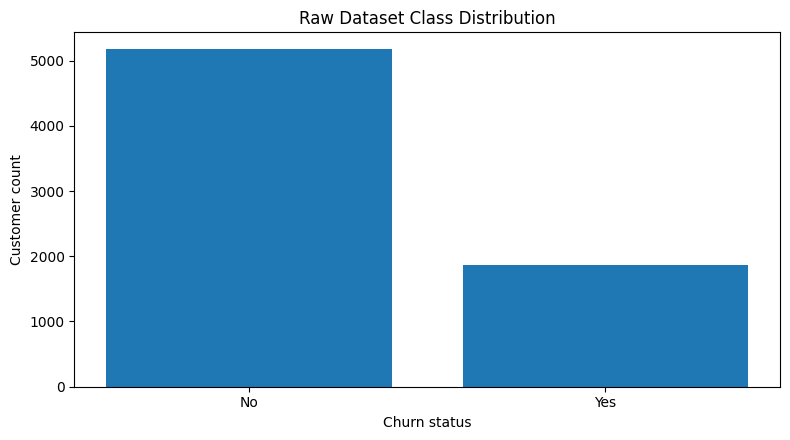

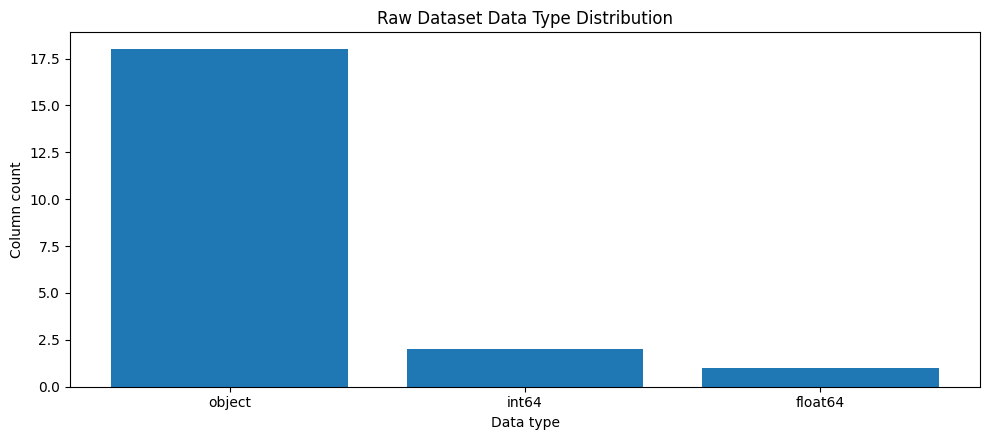

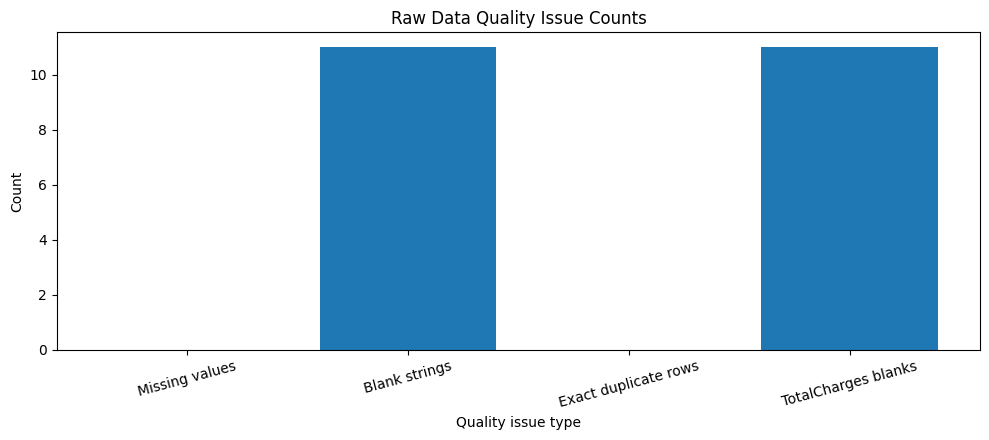

In [3]:
# ============================================================
# Raw data load and audit
# ============================================================

# Load the raw telco churn CSV after path detection and schema validation.
raw_df = pd.read_csv(RAW_DATASET_PATH)

# Show the basic structure of the raw dataset for audit and evidence.
print("Dataset shape:", raw_df.shape)
display(raw_df.head())
print("\nColumns in order:")
print(list(raw_df.columns))
print("\nDtypes:")
display(raw_df.dtypes.rename("dtype").reset_index().rename(columns={"index": "column"}))

# Work from a copy when creating audit summaries so the original raw frame remains untouched.
raw_df_for_audit = raw_df.copy()

# Summarize explicit missing values column by column.
missing_summary = raw_df.isna().sum().rename("missing_count").reset_index().rename(columns={"index": "column"})

# Count blank strings separately because TotalCharges often contains whitespace rather than true NaN values.
blank_string_records = []
for col in raw_df.columns:
    if raw_df[col].dtype == object:
        blank_count = raw_df[col].astype(str).str.strip().eq("").sum()
        blank_string_records.append({"column": col, "blank_string_count": int(blank_count)})
blank_string_summary = pd.DataFrame(blank_string_records)

# Count exact duplicate rows so duplicate handling is evidence-based rather than assumed.
duplicate_count = int(raw_df.duplicated().sum())

suspicious_object_columns = []
for col in raw_df.columns:
    if raw_df[col].dtype == object:
        stripped = raw_df[col].astype(str).str.strip()
        numeric_like_ratio = pd.to_numeric(stripped, errors="coerce").notna().mean()
        unique_count = stripped.nunique(dropna=False)
        suspicious_object_columns.append(
            {
                "column": col,
                "numeric_like_ratio": round(float(numeric_like_ratio), 4),
                "unique_count": int(unique_count),
            }
        )
suspicious_object_columns = pd.DataFrame(suspicious_object_columns).sort_values(
    by=["numeric_like_ratio", "unique_count"], ascending=[False, False]
)

totalcharges_blank_mask = raw_df["TotalCharges"].astype(str).str.strip().eq("")
totalcharges_blank_rows = raw_df.loc[totalcharges_blank_mask].copy()

class_counts = raw_df["Churn"].value_counts(dropna=False).rename_axis("Churn").reset_index(name="count")
class_counts["percentage"] = (class_counts["count"] / len(raw_df) * 100).round(2)

whitespace_audit = []
for col in raw_df.columns:
    if raw_df[col].dtype == object:
        series = raw_df[col].astype(str)
        leading_trailing_ws = int((series != series.str.strip()).sum())
        whitespace_audit.append(
            {
                "column": col,
                "leading_or_trailing_whitespace_rows": leading_trailing_ws
            }
        )
whitespace_audit = pd.DataFrame(whitespace_audit)

decision_log = pd.DataFrame(
    [
        {
            "decision_area": "Identifier handling",
            "decision": "Preserve customerID for traceability but exclude it from model fitting.",
            "reason": "customerID has traceability value but no substantive predictive meaning."
        },
        {
            "decision_area": "Target variable",
            "decision": "Use Churn as the target and encode it later as a binary field.",
            "reason": "Binary churn prediction is the dissertation target task."
        },
        {
            "decision_area": "TotalCharges handling",
            "decision": "Inspect blank strings explicitly, coerce TotalCharges to numeric, and resolve the resulting missing values transparently.",
            "reason": "TotalCharges is conceptually numeric but may contain blank-string rows."
        },
        {
            "decision_area": "Duplicate handling",
            "decision": f"Exact duplicate rows identified: {duplicate_count}.",
            "reason": "Visible audit before any removal or retention decision."
        },
        {
            "decision_area": "Leakage control",
            "decision": "Do not one-hot encode or scale outside model pipelines.",
            "reason": "Prevents train/test contamination and supports reproducibility."
        },
    ]
)

audit_summary = pd.DataFrame(
    [
        {"metric": "row_count", "value": int(raw_df.shape[0])},
        {"metric": "column_count", "value": int(raw_df.shape[1])},
        {"metric": "exact_duplicate_rows", "value": duplicate_count},
        {"metric": "target_column_present", "value": "Churn" in raw_df.columns},
        {"metric": "identifier_column_present", "value": "customerID" in raw_df.columns},
        {"metric": "totalcharges_blank_strings", "value": int(totalcharges_blank_mask.sum())},
    ]
)

display(audit_summary)
display(missing_summary)
display(blank_string_summary)
display(class_counts)
display(suspicious_object_columns)
display(whitespace_audit)
display(decision_log)

audit_summary.to_csv(PROJECT_ROOT / "exports" / "tables" / "telco_data_audit_summary.csv", index=False)
missing_summary.to_csv(PROJECT_ROOT / "exports" / "tables" / "telco_missingness_summary.csv", index=False)
class_counts.to_csv(PROJECT_ROOT / "exports" / "tables" / "telco_class_balance_summary.csv", index=False)
decision_log.to_csv(PROJECT_ROOT / "exports" / "qa" / "telco_decision_log.csv", index=False)
suspicious_object_columns.to_csv(PROJECT_ROOT / "exports" / "qa" / "telco_suspicious_object_columns.csv", index=False)
whitespace_audit.to_csv(PROJECT_ROOT / "exports" / "qa" / "telco_object_whitespace_audit.csv", index=False)
totalcharges_blank_rows.to_csv(PROJECT_ROOT / "exports" / "qa" / "telco_totalcharges_blank_rows.csv", index=False)

plt.figure(figsize=(8, 4.5))
plt.bar(class_counts["Churn"], class_counts["count"])
plt.title("Raw Dataset Class Distribution")
plt.xlabel("Churn status")
plt.ylabel("Customer count")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "eda" / "raw_class_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 4.5))
dtype_counts = raw_df.dtypes.astype(str).value_counts()
plt.bar(dtype_counts.index.astype(str), dtype_counts.values)
plt.title("Raw Dataset Data Type Distribution")
plt.xlabel("Data type")
plt.ylabel("Column count")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "eda" / "raw_dtype_distribution.png", dpi=300)
plt.show()

quality_issue_counts = pd.DataFrame(
    [
        {"issue": "Missing values", "count": int(missing_summary["missing_count"].sum())},
        {"issue": "Blank strings", "count": int(blank_string_summary["blank_string_count"].sum())},
        {"issue": "Exact duplicate rows", "count": duplicate_count},
        {"issue": "TotalCharges blanks", "count": int(totalcharges_blank_mask.sum())},
    ]
)
plt.figure(figsize=(10, 4.5))
plt.bar(quality_issue_counts["issue"], quality_issue_counts["count"])
plt.title("Raw Data Quality Issue Counts")
plt.xlabel("Quality issue type")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "eda" / "raw_quality_issue_counts.png", dpi=300)
plt.show()


In [4]:
# ============================================================
# Quality gate: post-audit
# ============================================================

# Initialize a central quality-gate log that will be appended across notebook stages.
quality_gate_records = []

# Define a reusable helper for recording QA checks in a consistent schema.
def add_quality_gate(stage, check_name, passed, details):
    quality_gate_records.append(
        {
            "stage": stage,
            "check_name": check_name,
            "passed": bool(passed),
            "details": sanitize_value(details, PROJECT_ROOT),
        }
    )

# Log the key post-audit checks immediately after the raw-data review.
add_quality_gate("post-audit", "target_column_present", "Churn" in raw_df.columns, "Churn column must exist.")
add_quality_gate("post-audit", "identifier_column_present", "customerID" in raw_df.columns, "customerID column must exist.")
add_quality_gate("post-audit", "exact_duplicate_rows_checked", True, f"Exact duplicates found: {duplicate_count}")
add_quality_gate("post-audit", "totalcharges_blanks_inspected", True, f"TotalCharges blank strings found: {int(totalcharges_blank_mask.sum())}")
add_quality_gate("post-audit", "class_distribution_reviewed", True, class_counts.to_dict(orient="records"))

# Materialize and export the current quality-gate table so early QA evidence is preserved.
quality_gate_df = pd.DataFrame(quality_gate_records)
display(quality_gate_df[quality_gate_df["stage"] == "post-audit"])


,stage,check_name,passed,details
0,post-audit,target_column_present,True,Churn column must exist.
1,post-audit,identifier_column_present,True,customerID column must exist.
2,post-audit,exact_duplicate_rows_checked,True,Exact duplicates found: 0
3,post-audit,totalcharges_blanks_inspected,True,TotalCharges blank strings found: 11
4,post-audit,class_distribution_reviewed,True,"[{'Churn': 'No', 'count': '5174', 'percentage'..."


## Cleaning and preprocessing policy
This section applies explicit cleaning decisions, creates dashboard-oriented derived fields, and prepares a clean analytical base dataset while preserving business-readable categories.

**Why this matters**
- It resolves `TotalCharges` safely.
- It preserves human-readable fields for later dashboard drill-down.
- It keeps modelling transforms inside pipelines, not in ad hoc preprocessing.

**Outputs to inspect**
- Cleaned dataset preview
- Derived feature summary
- Post-cleaning quality gate


In [5]:
# ============================================================
# Cleaning and preprocessing policy
# ============================================================

# Start cleaning from a fresh copy so raw_df remains available for audit reference.
clean_df = raw_df.copy()
# Normalize column names and object values by stripping accidental whitespace.
clean_df.columns = [col.strip() for col in clean_df.columns]
for col in clean_df.columns:
    if clean_df[col].dtype == object:
        clean_df[col] = clean_df[col].astype(str).str.strip()
for col in clean_df.columns:
    if clean_df[col].dtype == object:
        clean_df[col] = clean_df[col].replace({"nan": np.nan})

# Preserve the raw TotalCharges field before coercion for traceability and diagnostics.
clean_df["TotalCharges_raw"] = clean_df["TotalCharges"]
clean_df["TotalCharges"] = pd.to_numeric(clean_df["TotalCharges"], errors="coerce")

# Inspect rows that became missing after numeric coercion and then remove the unresolved cases.
totalcharges_nan_after_coercion = clean_df["TotalCharges"].isna().sum()
rows_with_totalcharges_nan = clean_df.loc[clean_df["TotalCharges"].isna()].copy()
clean_df = clean_df.dropna(subset=["TotalCharges"]).reset_index(drop=True)

# Create both a readable churn label and a binary modelling target.
clean_df["actual_churn_label"] = clean_df["Churn"].map({"Yes": "Yes", "No": "No"})
clean_df["churn_binary"] = clean_df["Churn"].map({"Yes": 1, "No": 0}).astype(int)

# Define reusable bucketing helpers so dashboard segmentation rules are explicit and stable.
def tenure_bucket(value):
    if value <= 12:
        return "0-12 months"
    elif value <= 24:
        return "13-24 months"
    elif value <= 48:
        return "25-48 months"
    else:
        return "49+ months"

# Add dashboard-oriented derived features used for segmentation, prioritization, and explanation.
clean_df["tenure_group"] = clean_df["tenure"].apply(tenure_bucket)

monthly_edges = [-np.inf, 35, 70, 100, np.inf]
monthly_labels = ["Low", "Moderate", "High", "Very High"]
clean_df["monthly_charge_band"] = pd.cut(
    clean_df["MonthlyCharges"],
    bins=monthly_edges,
    labels=monthly_labels,
    include_lowest=True,
).astype(str)

total_edges = [-np.inf, 500, 1500, 3000, np.inf]
total_labels = ["Low Lifetime Value", "Moderate Lifetime Value", "High Lifetime Value", "Very High Lifetime Value"]
clean_df["total_charge_band"] = pd.cut(
    clean_df["TotalCharges"],
    bins=total_edges,
    labels=total_labels,
    include_lowest=True,
).astype(str)

service_columns = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
]

clean_df["service_count"] = (
    clean_df["PhoneService"].eq("Yes").astype(int)
    + clean_df["MultipleLines"].eq("Yes").astype(int)
    + clean_df["InternetService"].isin(["DSL", "Fiber optic"]).astype(int)
    + clean_df["OnlineSecurity"].eq("Yes").astype(int)
    + clean_df["OnlineBackup"].eq("Yes").astype(int)
    + clean_df["DeviceProtection"].eq("Yes").astype(int)
    + clean_df["TechSupport"].eq("Yes").astype(int)
    + clean_df["StreamingTV"].eq("Yes").astype(int)
    + clean_df["StreamingMovies"].eq("Yes").astype(int)
)

clean_df["support_services_count"] = (
    clean_df["OnlineSecurity"].eq("Yes").astype(int)
    + clean_df["OnlineBackup"].eq("Yes").astype(int)
    + clean_df["DeviceProtection"].eq("Yes").astype(int)
    + clean_df["TechSupport"].eq("Yes").astype(int)
)

clean_df["streaming_services_count"] = (
    clean_df["StreamingTV"].eq("Yes").astype(int)
    + clean_df["StreamingMovies"].eq("Yes").astype(int)
)

clean_df["has_fiber_optic"] = np.where(clean_df["InternetService"].eq("Fiber optic"), "Yes", "No")
clean_df["is_month_to_month"] = np.where(clean_df["Contract"].eq("Month-to-month"), "Yes", "No")
clean_df["uses_electronic_check"] = np.where(clean_df["PaymentMethod"].eq("Electronic check"), "Yes", "No")
clean_df["is_senior_citizen_flag"] = np.where(clean_df["SeniorCitizen"].eq(1), "Yes", "No")
clean_df["dataset_partition"] = "full_dataset"

feature_summary_table = pd.DataFrame(
    [
        {"feature_group": "identifier", "feature_name": "customerID", "role": "traceability only"},
        {"feature_group": "target", "feature_name": "Churn", "role": "raw human-readable target"},
        {"feature_group": "target", "feature_name": "churn_binary", "role": "binary modelling target"},
        {"feature_group": "derived_dashboard", "feature_name": "tenure_group", "role": "segment exploration"},
        {"feature_group": "derived_dashboard", "feature_name": "monthly_charge_band", "role": "segment exploration"},
        {"feature_group": "derived_dashboard", "feature_name": "total_charge_band", "role": "segment exploration"},
        {"feature_group": "derived_dashboard", "feature_name": "service_count", "role": "portfolio and segment analysis"},
        {"feature_group": "derived_dashboard", "feature_name": "support_services_count", "role": "portfolio and segment analysis"},
        {"feature_group": "derived_dashboard", "feature_name": "streaming_services_count", "role": "portfolio and segment analysis"},
        {"feature_group": "derived_dashboard", "feature_name": "has_fiber_optic", "role": "segment exploration"},
        {"feature_group": "derived_dashboard", "feature_name": "is_month_to_month", "role": "segment exploration"},
        {"feature_group": "derived_dashboard", "feature_name": "uses_electronic_check", "role": "segment exploration"},
        {"feature_group": "derived_dashboard", "feature_name": "is_senior_citizen_flag", "role": "segment exploration"},
    ]
)

display(clean_df.head())
display(rows_with_totalcharges_nan.head())
display(feature_summary_table)

clean_df.to_csv(PROJECT_ROOT / "data" / "processed" / "telco_cleaned_base_dataset.csv", index=False)
clean_df.head(200).to_csv(PROJECT_ROOT / "data" / "processed" / "telco_model_ready_audit_snapshot.csv", index=False)
feature_summary_table.to_csv(PROJECT_ROOT / "exports" / "tables" / "telco_feature_summary_table.csv", index=False)

# Record cleaning-stage quality checks after the processed dataset has been created.
add_quality_gate("post-cleaning", "totalcharges_numeric_coercion_applied", True, f"Rows with NaN after coercion: {int(totalcharges_nan_after_coercion)}")
add_quality_gate("post-cleaning", "unresolved_totalcharges_rows_removed", True, f"Rows removed after inspection: {int(len(rows_with_totalcharges_nan))}")
add_quality_gate("post-cleaning", "target_encoded_binary", set(clean_df["churn_binary"].unique()).issubset({0,1}), "Binary target created as churn_binary.")
add_quality_gate("post-cleaning", "customerid_preserved_for_traceability", "customerID" in clean_df.columns, "customerID retained in clean dataset.")
add_quality_gate("post-cleaning", "derived_dashboard_fields_created", True, "All required dashboard-oriented derived fields created.")

display(pd.DataFrame(quality_gate_records)[pd.DataFrame(quality_gate_records)["stage"] == "post-cleaning"])


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,monthly_charge_band,total_charge_band,service_count,support_services_count,streaming_services_count,has_fiber_optic,is_month_to_month,uses_electronic_check,is_senior_citizen_flag,dataset_partition
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Low,Low Lifetime Value,2,1,0,No,Yes,Yes,No,full_dataset
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Moderate,High Lifetime Value,4,2,0,No,No,No,No,full_dataset
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Moderate,Low Lifetime Value,4,2,0,No,Yes,No,No,full_dataset
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Moderate,High Lifetime Value,4,3,0,No,No,No,No,full_dataset
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,High,Low Lifetime Value,2,0,0,Yes,Yes,Yes,No,full_dataset


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_raw
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,


,feature_group,feature_name,role
0,identifier,customerID,traceability only
1,target,Churn,raw human-readable target
2,target,churn_binary,binary modelling target
3,derived_dashboard,tenure_group,segment exploration
4,derived_dashboard,monthly_charge_band,segment exploration
5,derived_dashboard,total_charge_band,segment exploration
6,derived_dashboard,service_count,portfolio and segment analysis
7,derived_dashboard,support_services_count,portfolio and segment analysis
8,derived_dashboard,streaming_services_count,portfolio and segment analysis
9,derived_dashboard,has_fiber_optic,segment exploration


,stage,check_name,passed,details
5,post-cleaning,totalcharges_numeric_coercion_applied,True,Rows with NaN after coercion: 11
6,post-cleaning,unresolved_totalcharges_rows_removed,True,Rows removed after inspection: 11
7,post-cleaning,target_encoded_binary,True,Binary target created as churn_binary.
8,post-cleaning,customerid_preserved_for_traceability,True,customerID retained in clean dataset.
9,post-cleaning,derived_dashboard_fields_created,True,All required dashboard-oriented derived fields...


## Focused exploratory data analysis
This section produces purposeful visuals that answer business and modelling questions rather than decorative charts.

**Why this matters**
- It shows where churn is concentrated.
- It improves interpretability before modelling.
- It feeds figures and dashboard segment logic.

**Outputs to inspect**
- Saved EDA figures
- Segment summary tables
- Post-EDA quality gate


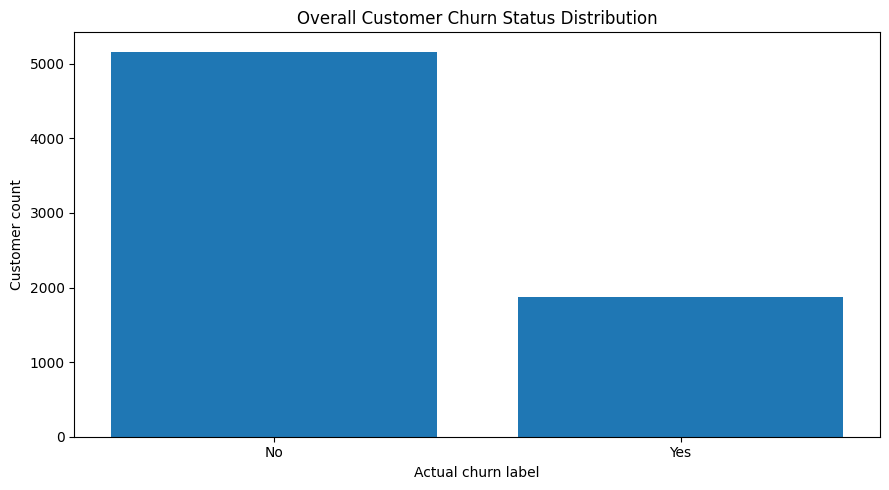

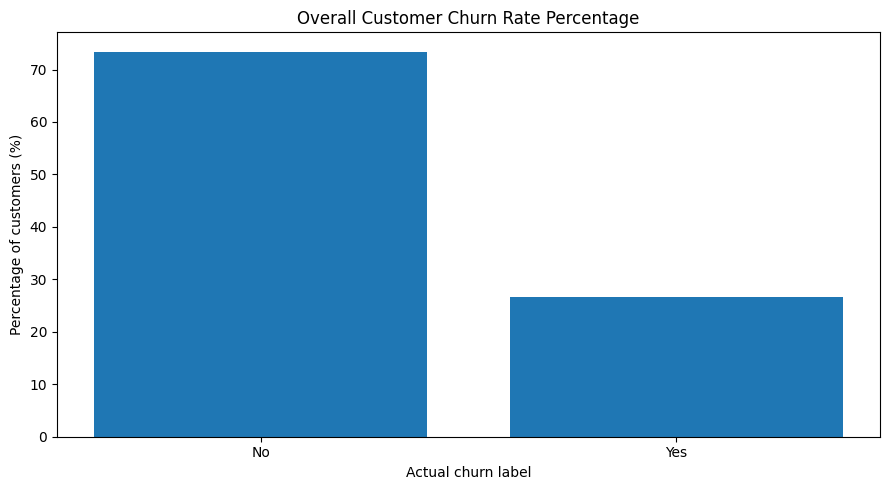

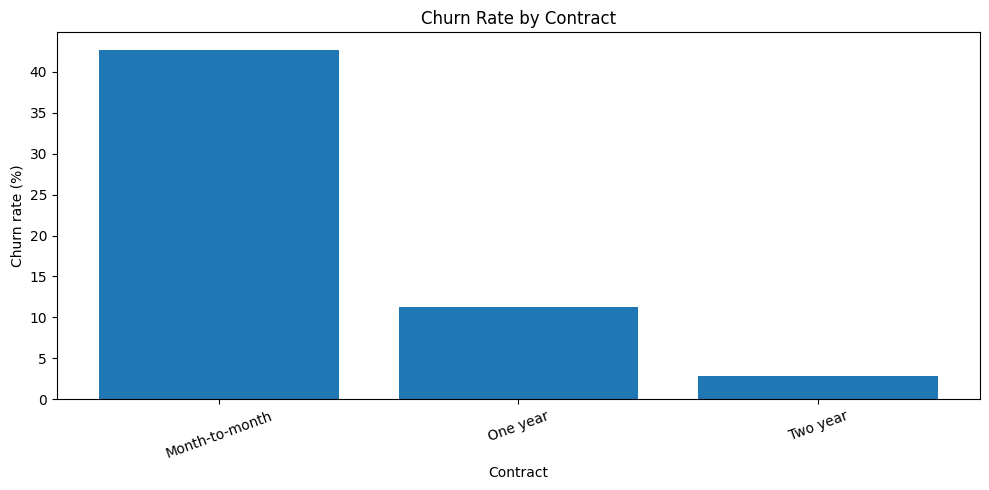

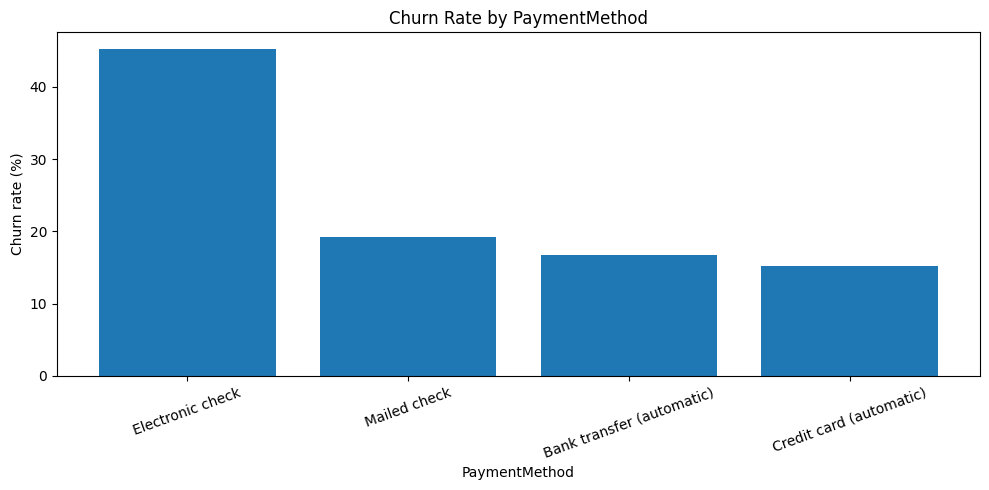

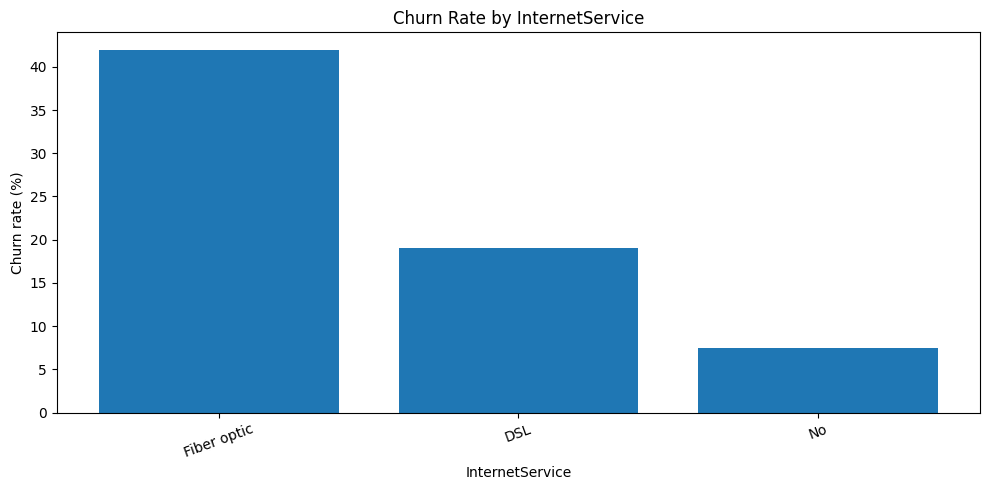

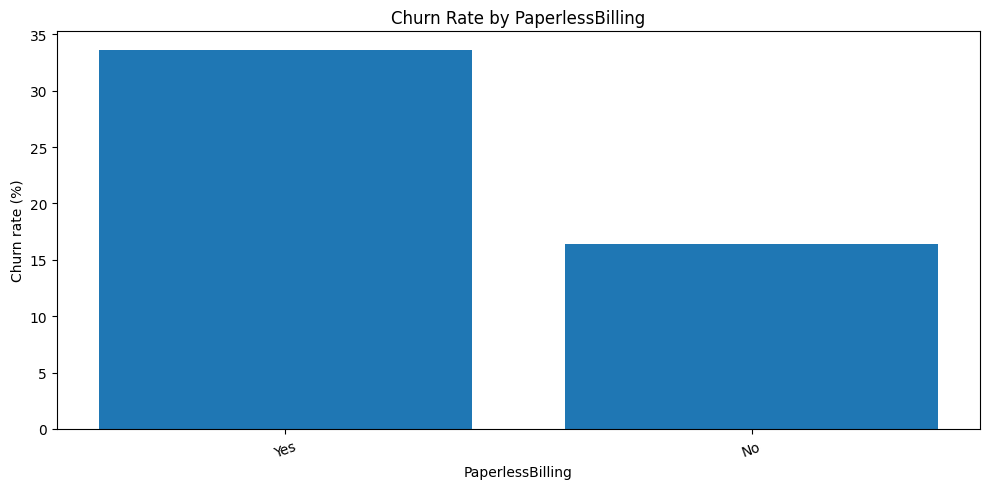

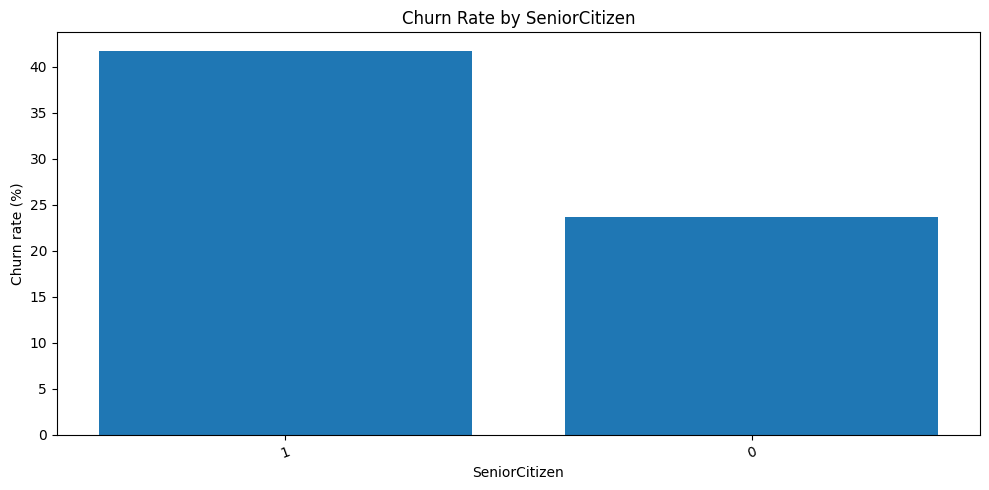

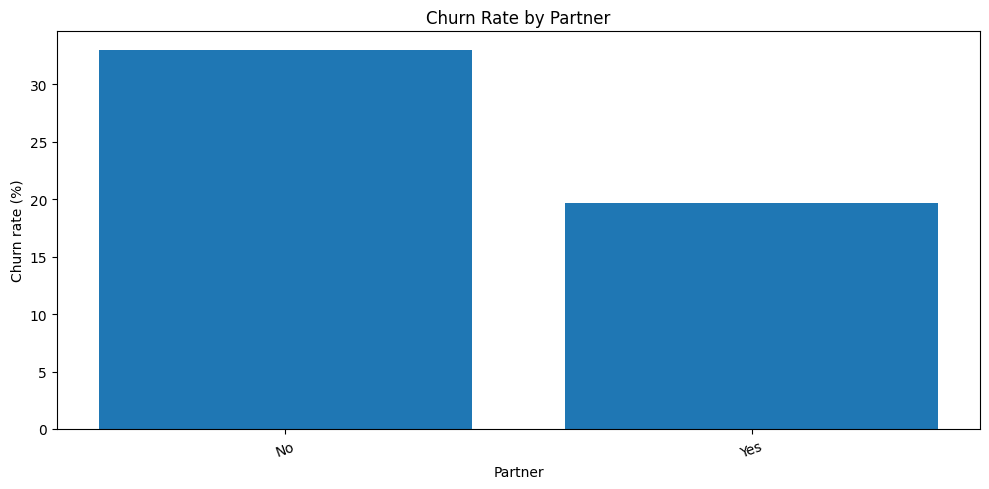

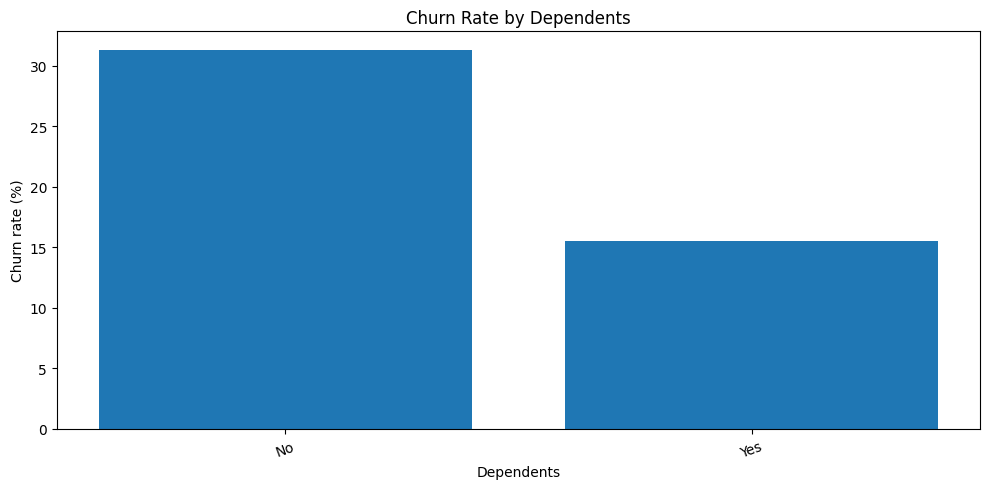

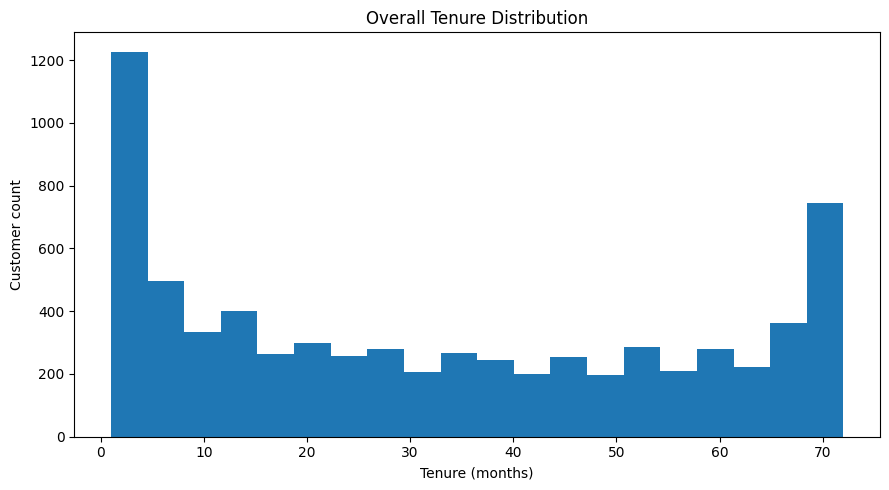

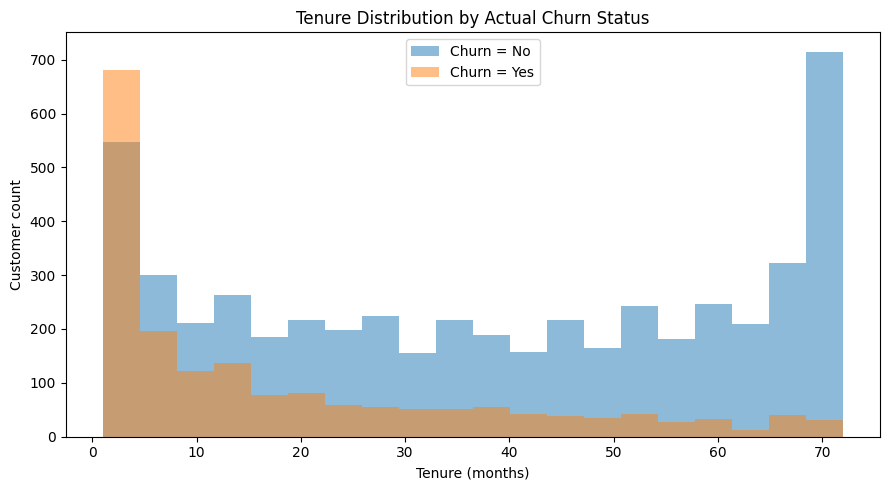

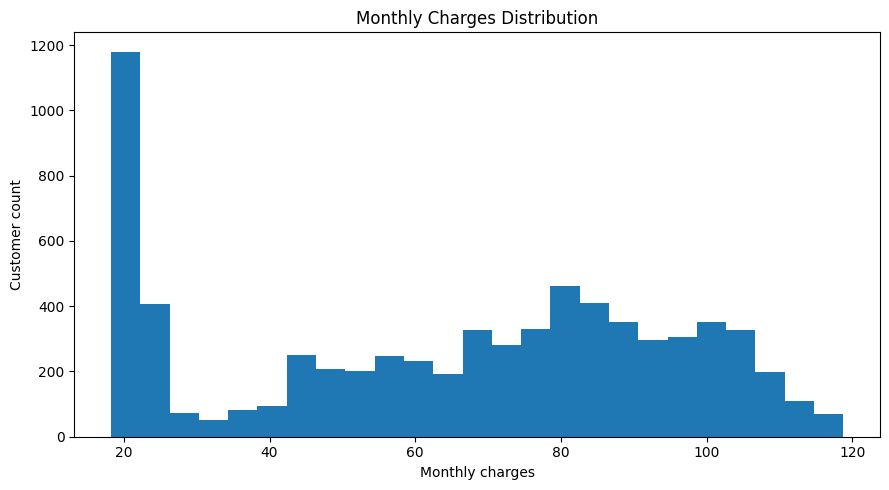

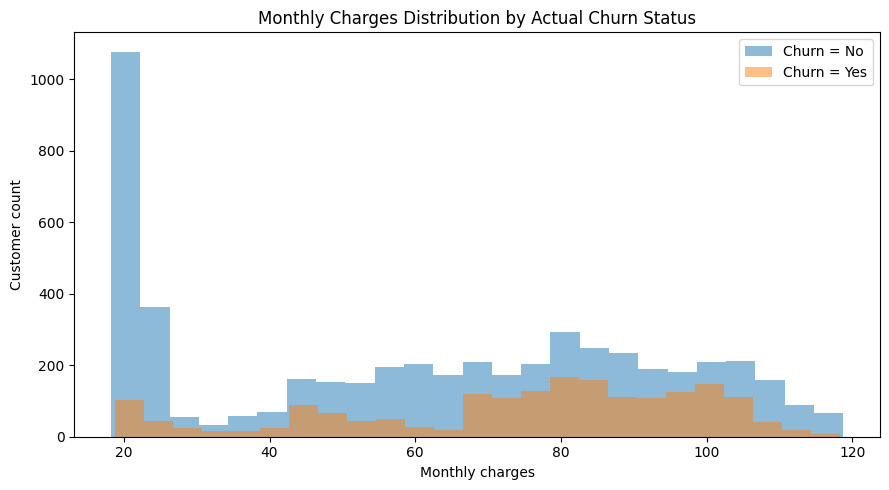

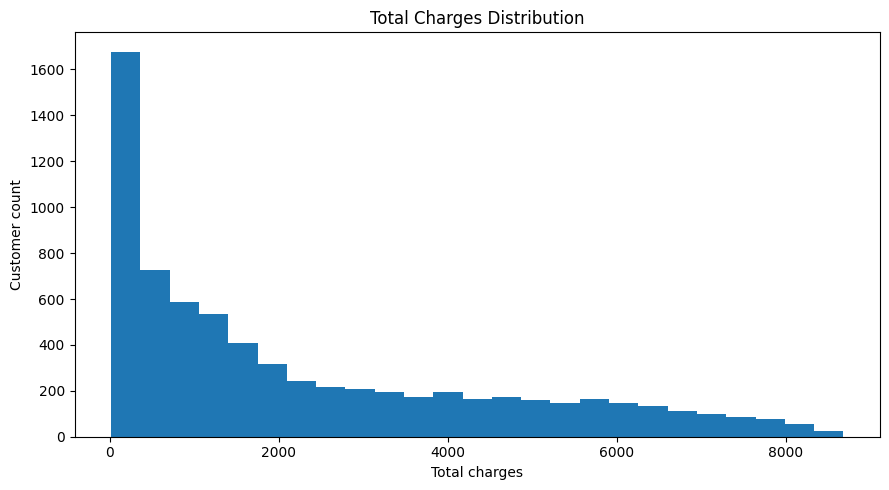

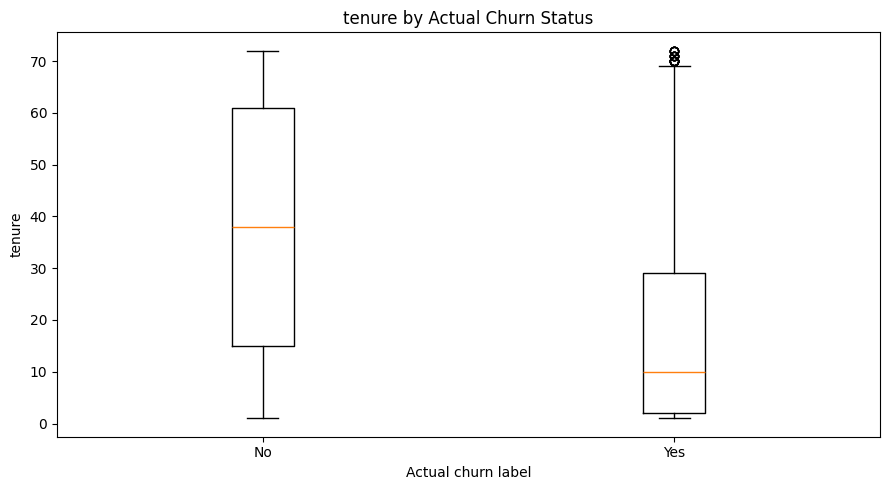

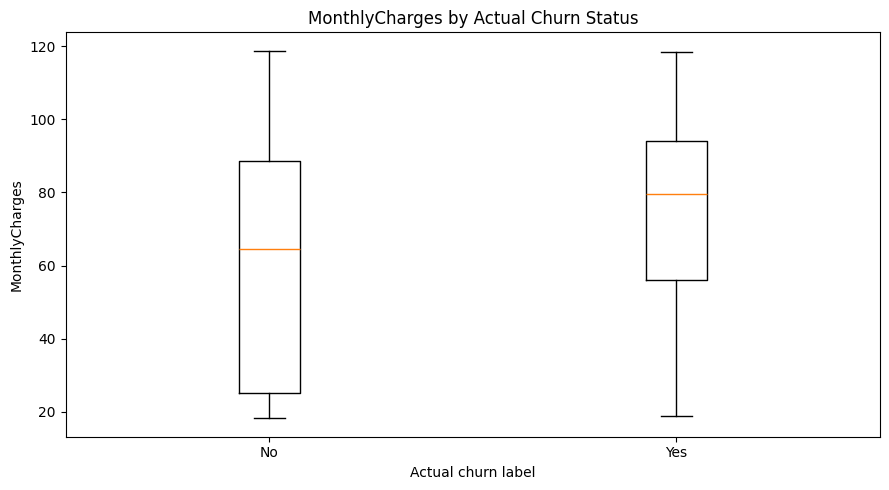

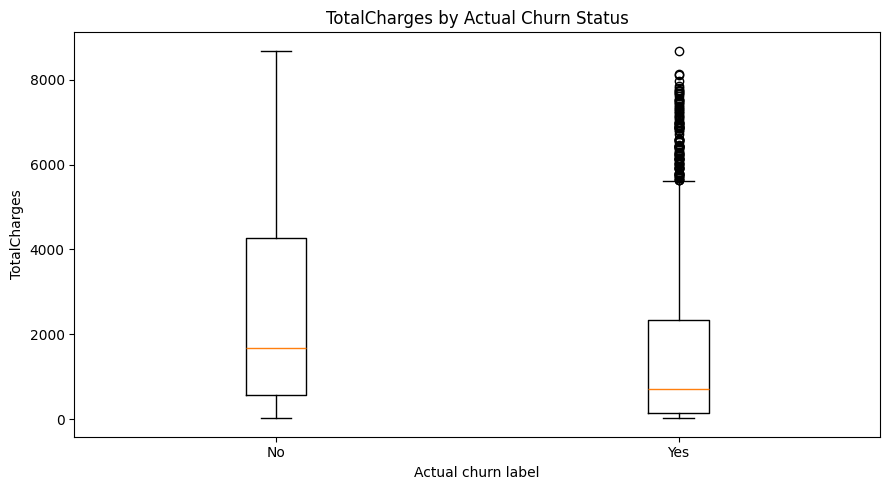

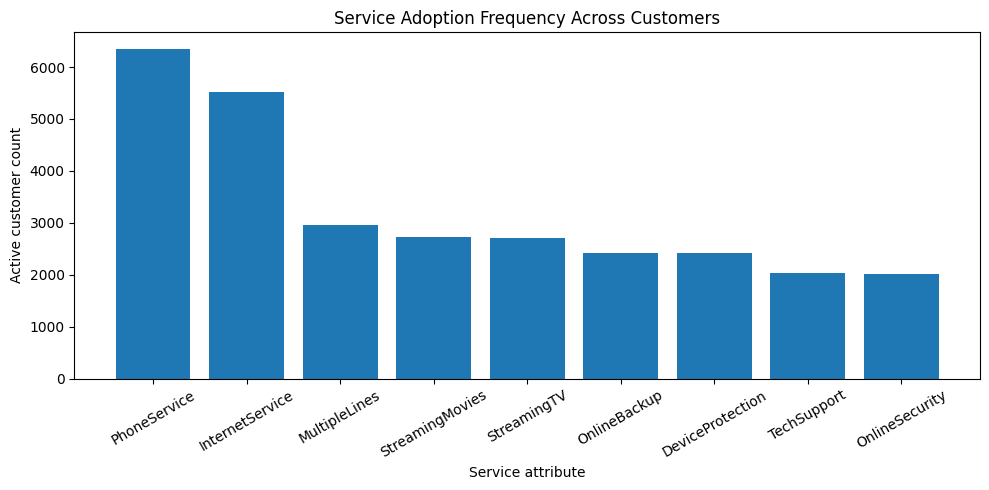

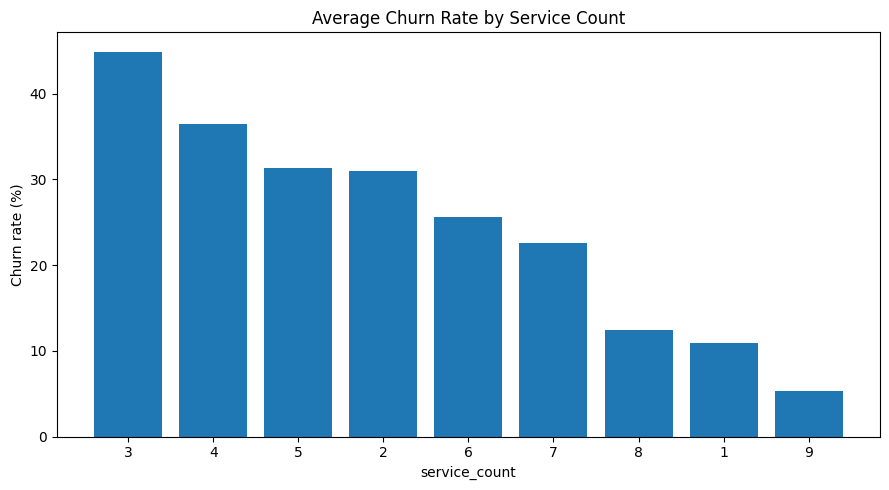

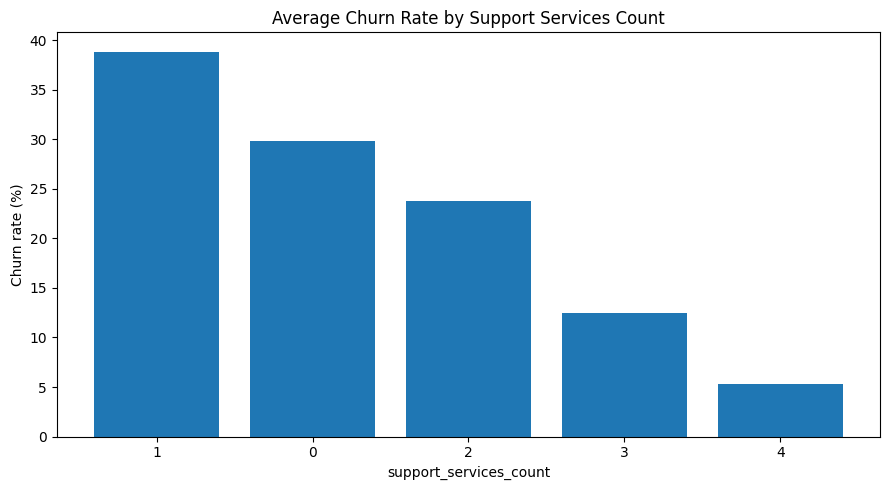

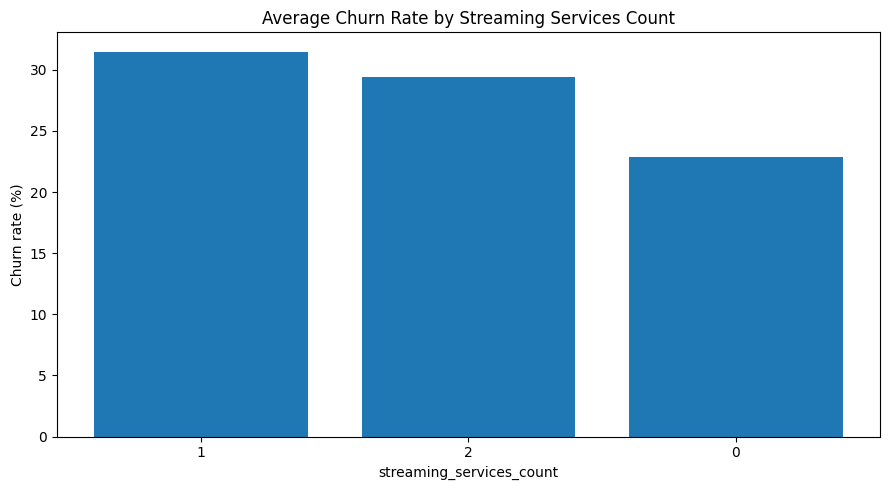

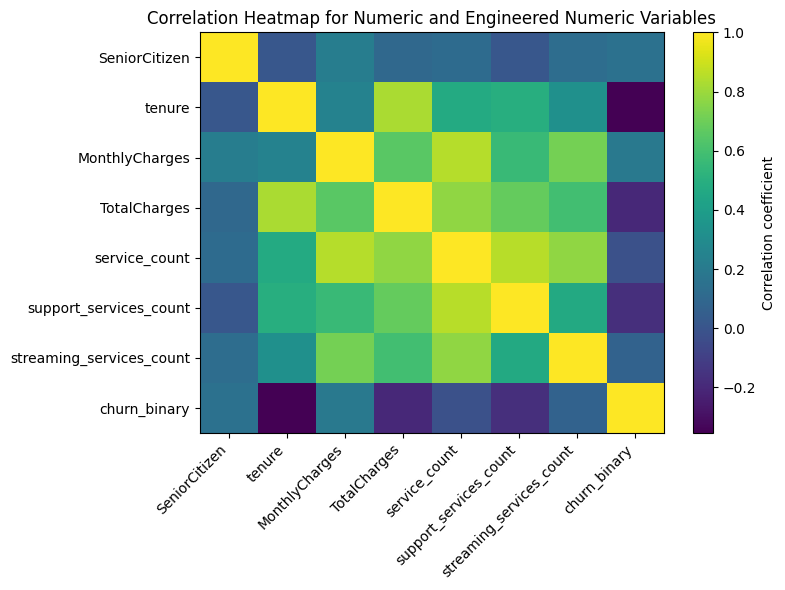

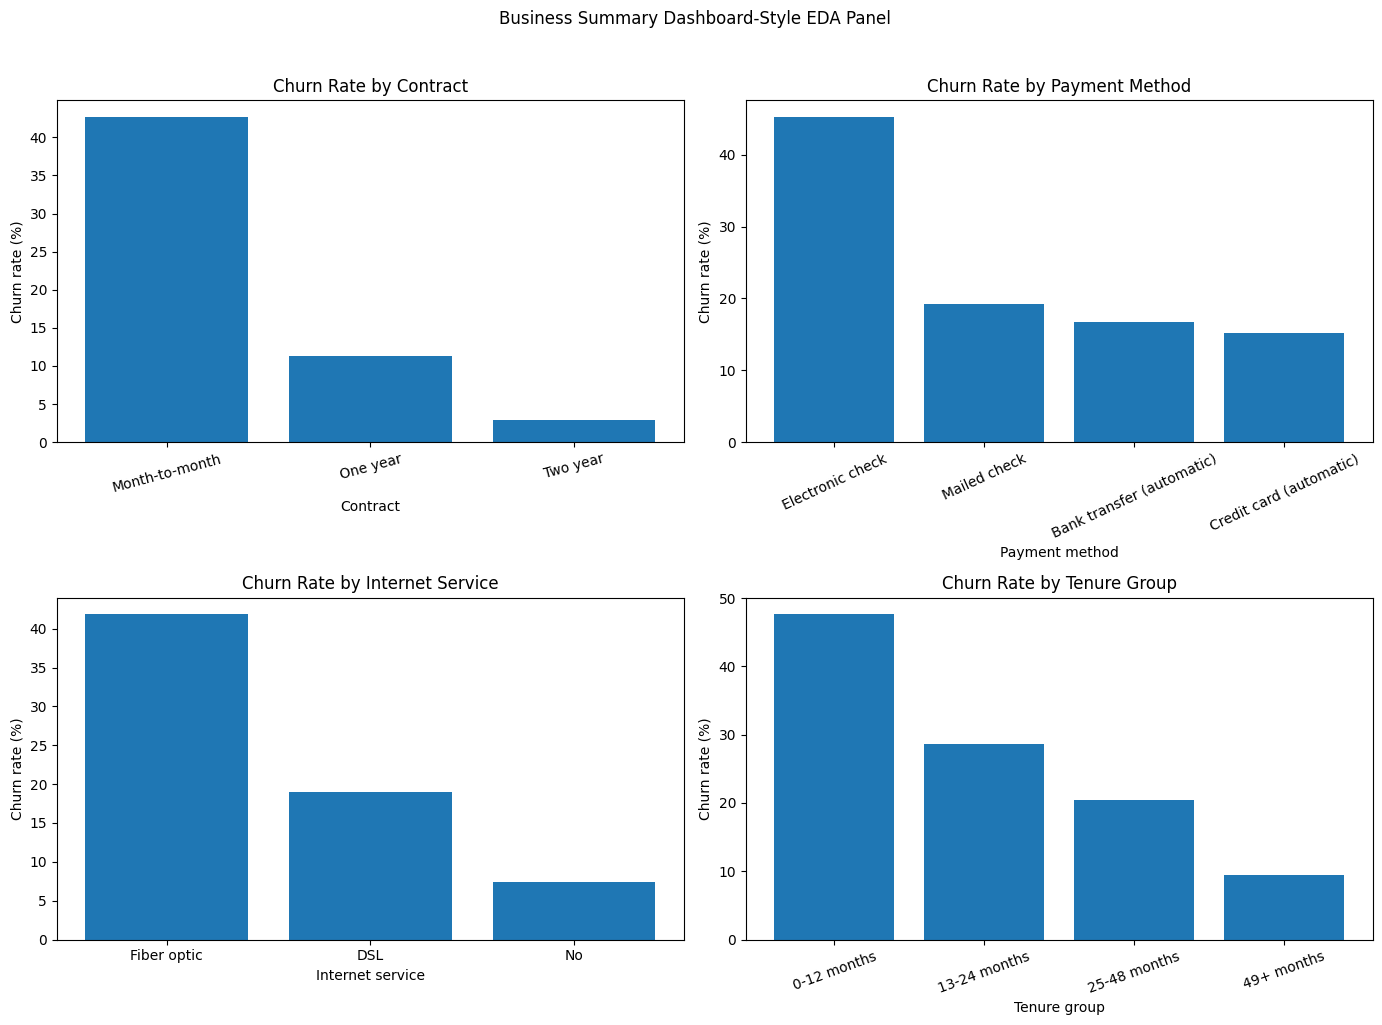

,stage,check_name,passed,details
10,post-EDA,eda_figures_generated,True,Core EDA figures saved under figures/eda.
11,post-EDA,segment_summaries_exported,True,"Contract, payment method, and internet service..."
12,post-EDA,eda_answers_business_questions,True,"EDA covers churn concentration, charges, tenur..."


In [6]:
# ============================================================
# Focused exploratory data analysis
# ============================================================

# Set a default figure size so exploratory charts remain readable and consistent.
plt.rcParams["figure.figsize"] = (9, 5)

# Use one helper to apply tight layout, save the figure, and display it consistently.
def save_and_show(fig_path):
    plt.tight_layout()
    plt.savefig(fig_path, dpi=300)
    plt.show()

# Compute counts and churn rates by segment for the recurring EDA summaries below.
def churn_rate_by(df, group_col):
    temp = (
        df.groupby(group_col, dropna=False)["churn_binary"]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"mean": "churn_rate"})
    )
    temp["churn_rate_pct"] = (temp["churn_rate"] * 100).round(2)
    return temp.sort_values(by="churn_rate_pct", ascending=False)

# Summarize the overall churn class distribution before moving into segment-level patterns.
overall_churn = clean_df["actual_churn_label"].value_counts().rename_axis("actual_churn_label").reset_index(name="count")
overall_churn["percentage"] = (overall_churn["count"] / len(clean_df) * 100).round(2)

plt.figure()
plt.bar(overall_churn["actual_churn_label"], overall_churn["count"])
plt.title("Overall Customer Churn Status Distribution")
plt.xlabel("Actual churn label")
plt.ylabel("Customer count")
save_and_show(PROJECT_ROOT / "figures" / "eda" / "overall_churn_status_distribution.png")

plt.figure()
plt.bar(overall_churn["actual_churn_label"], overall_churn["percentage"])
plt.title("Overall Customer Churn Rate Percentage")
plt.xlabel("Actual churn label")
plt.ylabel("Percentage of customers (%)")
save_and_show(PROJECT_ROOT / "figures" / "eda" / "overall_churn_rate_percentage.png")

for col, fname in [
    ("Contract", "churn_by_contract_type.png"),
    ("PaymentMethod", "churn_by_payment_method.png"),
    ("InternetService", "churn_by_internet_service.png"),
    ("PaperlessBilling", "churn_by_paperless_billing.png"),
    ("SeniorCitizen", "churn_by_senior_citizen.png"),
    ("Partner", "churn_by_partner_status.png"),
    ("Dependents", "churn_by_dependents_status.png"),
]:
    summary = churn_rate_by(clean_df, col)
    plt.figure(figsize=(10, 5))
    plt.bar(summary[col].astype(str), summary["churn_rate_pct"])
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn rate (%)")
    plt.xticks(rotation=20)
    save_and_show(PROJECT_ROOT / "figures" / "eda" / fname)

plt.figure()
plt.hist(clean_df["tenure"], bins=20)
plt.title("Overall Tenure Distribution")
plt.xlabel("Tenure (months)")
plt.ylabel("Customer count")
save_and_show(PROJECT_ROOT / "figures" / "eda" / "tenure_distribution_overall.png")

plt.figure()
for label in ["No", "Yes"]:
    plt.hist(
        clean_df.loc[clean_df["actual_churn_label"] == label, "tenure"],
        bins=20,
        alpha=0.5,
        label=f"Churn = {label}",
    )
plt.title("Tenure Distribution by Actual Churn Status")
plt.xlabel("Tenure (months)")
plt.ylabel("Customer count")
plt.legend()
save_and_show(PROJECT_ROOT / "figures" / "eda" / "tenure_distribution_by_churn.png")

plt.figure()
plt.hist(clean_df["MonthlyCharges"], bins=25)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly charges")
plt.ylabel("Customer count")
save_and_show(PROJECT_ROOT / "figures" / "eda" / "monthly_charges_distribution_overall.png")

plt.figure()
for label in ["No", "Yes"]:
    plt.hist(
        clean_df.loc[clean_df["actual_churn_label"] == label, "MonthlyCharges"],
        bins=25,
        alpha=0.5,
        label=f"Churn = {label}",
    )
plt.title("Monthly Charges Distribution by Actual Churn Status")
plt.xlabel("Monthly charges")
plt.ylabel("Customer count")
plt.legend()
save_and_show(PROJECT_ROOT / "figures" / "eda" / "monthly_charges_distribution_by_churn.png")

plt.figure()
plt.hist(clean_df["TotalCharges"], bins=25)
plt.title("Total Charges Distribution")
plt.xlabel("Total charges")
plt.ylabel("Customer count")
save_and_show(PROJECT_ROOT / "figures" / "eda" / "total_charges_distribution_overall.png")

for numeric_col, fname, xlabel in [
    ("tenure", "boxplot_tenure_by_churn.png", "Actual churn label"),
    ("MonthlyCharges", "boxplot_monthlycharges_by_churn.png", "Actual churn label"),
    ("TotalCharges", "boxplot_totalcharges_by_churn.png", "Actual churn label"),
]:
    data = [
        clean_df.loc[clean_df["actual_churn_label"] == "No", numeric_col],
        clean_df.loc[clean_df["actual_churn_label"] == "Yes", numeric_col],
    ]
    plt.figure()
    plt.boxplot(data, labels=["No", "Yes"])
    plt.title(f"{numeric_col} by Actual Churn Status")
    plt.xlabel(xlabel)
    plt.ylabel(numeric_col)
    save_and_show(PROJECT_ROOT / "figures" / "eda" / fname)

service_adoption = []
for col in service_columns:
    if col in clean_df.columns:
        positive_count = int(clean_df[col].isin(["Yes", "DSL", "Fiber optic"]).sum())
        service_adoption.append({"service": col, "active_count": positive_count})
service_adoption = pd.DataFrame(service_adoption).sort_values(by="active_count", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(service_adoption["service"], service_adoption["active_count"])
plt.title("Service Adoption Frequency Across Customers")
plt.xlabel("Service attribute")
plt.ylabel("Active customer count")
plt.xticks(rotation=30)
save_and_show(PROJECT_ROOT / "figures" / "eda" / "service_adoption_frequency.png")

for col, fname, title in [
    ("service_count", "service_count_vs_churn.png", "Average Churn Rate by Service Count"),
    ("support_services_count", "support_services_vs_churn.png", "Average Churn Rate by Support Services Count"),
    ("streaming_services_count", "streaming_services_vs_churn.png", "Average Churn Rate by Streaming Services Count"),
]:
    summary = churn_rate_by(clean_df, col)
    plt.figure()
    plt.bar(summary[col].astype(str), summary["churn_rate_pct"])
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Churn rate (%)")
    save_and_show(PROJECT_ROOT / "figures" / "eda" / fname)

numeric_corr_cols = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "service_count",
    "support_services_count",
    "streaming_services_count",
    "churn_binary",
]
corr_matrix = clean_df[numeric_corr_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap for Numeric and Engineered Numeric Variables")
save_and_show(PROJECT_ROOT / "figures" / "eda" / "numeric_correlation_heatmap.png")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Compare churn behaviour across contract types, which is typically a strong churn driver.
contract_summary = churn_rate_by(clean_df, "Contract")
axes[0, 0].bar(contract_summary["Contract"], contract_summary["churn_rate_pct"])
axes[0, 0].set_title("Churn Rate by Contract")
axes[0, 0].set_xlabel("Contract")
axes[0, 0].set_ylabel("Churn rate (%)")
axes[0, 0].tick_params(axis="x", rotation=15)

# Review churn rates by payment method to identify operational billing-related risk patterns.
payment_summary = churn_rate_by(clean_df, "PaymentMethod")
axes[0, 1].bar(payment_summary["PaymentMethod"], payment_summary["churn_rate_pct"])
axes[0, 1].set_title("Churn Rate by Payment Method")
axes[0, 1].set_xlabel("Payment method")
axes[0, 1].set_ylabel("Churn rate (%)")
axes[0, 1].tick_params(axis="x", rotation=25)

# Review churn rates by internet service type to surface product-level differences.
internet_summary = churn_rate_by(clean_df, "InternetService")
axes[1, 0].bar(internet_summary["InternetService"], internet_summary["churn_rate_pct"])
axes[1, 0].set_title("Churn Rate by Internet Service")
axes[1, 0].set_xlabel("Internet service")
axes[1, 0].set_ylabel("Churn rate (%)")

tenure_summary = churn_rate_by(clean_df, "tenure_group")
axes[1, 1].bar(tenure_summary["tenure_group"], tenure_summary["churn_rate_pct"])
axes[1, 1].set_title("Churn Rate by Tenure Group")
axes[1, 1].set_xlabel("Tenure group")
axes[1, 1].set_ylabel("Churn rate (%)")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.suptitle("Business Summary Dashboard-Style EDA Panel", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "eda" / "business_summary_multipanel.png", dpi=300)
plt.show()

segment_contract = churn_rate_by(clean_df, "Contract")
segment_payment = churn_rate_by(clean_df, "PaymentMethod")
segment_internet = churn_rate_by(clean_df, "InternetService")

segment_contract.to_csv(PROJECT_ROOT / "exports" / "dashboard" / "telco_segment_summary_by_contract.csv", index=False)
segment_payment.to_csv(PROJECT_ROOT / "exports" / "dashboard" / "telco_segment_summary_by_payment_method.csv", index=False)
segment_internet.to_csv(PROJECT_ROOT / "exports" / "dashboard" / "telco_segment_summary_by_internet_service.csv", index=False)

add_quality_gate("post-EDA", "eda_figures_generated", True, "Core EDA figures saved under figures/eda.")
add_quality_gate("post-EDA", "segment_summaries_exported", True, "Contract, payment method, and internet service summaries exported.")
add_quality_gate("post-EDA", "eda_answers_business_questions", True, "EDA covers churn concentration, charges, tenure, services, and key segments.")

display(pd.DataFrame(quality_gate_records)[pd.DataFrame(quality_gate_records)["stage"] == "post-EDA"])


## Train/test split
This section creates the hold-out test set once, preserves class ratio via stratification, and stores a partition flag for downstream exports.

**Why this matters**
- It protects the final evaluation from contamination.
- It supports traceability in dashboard exports.
- It aligns with the validity requirements.

**Outputs to inspect**
- Split summary table
- Partition flag counts


In [7]:
# ============================================================
# Train/test split
# ============================================================

# Define the original business fields that should remain available for dashboard drill-down and exports.
original_business_fields = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
]

# Track the derived dashboard fields separately from the model-input fields.
dashboard_derived_fields = [
    "tenure_group",
    "monthly_charge_band",
    "total_charge_band",
    "service_count",
    "support_services_count",
    "streaming_services_count",
    "has_fiber_optic",
    "is_month_to_month",
    "uses_electronic_check",
    "is_senior_citizen_flag",
]

# Declare the identifier, target, and model-input field list used for splitting and modelling.
identifier_column = "customerID"
target_column = "churn_binary"
model_input_features = original_business_fields.copy()

# Build the modelling design matrix and target vector from the cleaned dataset.
X = clean_df[model_input_features].copy()
y = clean_df[target_column].copy()

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    clean_df.index,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

clean_df.loc[idx_train, "dataset_partition"] = "train"
clean_df.loc[idx_test, "dataset_partition"] = "test"

split_summary = pd.DataFrame(
    [
        {
            "partition": "train",
            "row_count": int(len(X_train)),
            "churn_rate_pct": round(float(y_train.mean() * 100), 2),
        },
        {
            "partition": "test",
            "row_count": int(len(X_test)),
            "churn_rate_pct": round(float(y_test.mean() * 100), 2),
        },
        {
            "partition": "full_dataset",
            "row_count": int(len(clean_df)),
            "churn_rate_pct": round(float(clean_df[target_column].mean() * 100), 2),
        },
    ]
)

display(split_summary)
display(clean_df["dataset_partition"].value_counts().rename_axis("dataset_partition").reset_index(name="count"))

split_summary.to_csv(PROJECT_ROOT / "exports" / "qa" / "telco_train_test_split_summary.csv", index=False)

add_quality_gate("post-modelling-setup", "stratified_split_created_once", True, "A single stratified 80/20 split was created.")
add_quality_gate("post-modelling-setup", "dataset_partition_flag_created", True, "dataset_partition column created with train/test labels.")


,partition,row_count,churn_rate_pct
0,train,5625,26.58
1,test,1407,26.58
2,full_dataset,7032,26.58


,dataset_partition,count
0,train,5625
1,test,1407


## Pipeline definitions
This section defines leakage-safe modelling pipelines using `ColumnTransformer` and `Pipeline`. Categorical encoding and scaling are learned only on training data.

**Why this matters**
- It prevents leakage.
- It keeps the workflow reproducible.
- It supports fair model comparison under the same governance.

**Outputs to inspect**
- Numeric and categorical feature lists
- Pipeline summary notes


In [8]:
# ============================================================
# Pipeline definitions
# ============================================================

# Separate numeric and categorical features so each receives the correct preprocessing steps.
numeric_features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [col for col in model_input_features if col not in numeric_features]

print("Identifier exclusion:", identifier_column)
print("Target variable:", target_column)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Dashboard-only derived fields:", dashboard_derived_fields)
print("Model-input feature set:", model_input_features)

# Logistic regression uses imputation plus scaling on numeric features.
lr_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Logistic regression uses imputation plus one-hot encoding on categorical features.
lr_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe()),
    ]
)

# Combine the numeric and categorical transforms into one leakage-safe preprocessor.
lr_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", lr_numeric_transformer, numeric_features),
        ("categorical", lr_categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

# Wrap preprocessing and the classifier together so all fitting happens inside the pipeline.
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", lr_preprocessor),
        ("classifier", LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE
        )),
    ]
)

# Random forest still uses imputation on numeric inputs but does not require scaling.
rf_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

rf_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe()),
    ]
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", rf_numeric_transformer, numeric_features),
        ("categorical", rf_categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

# Build the random forest pipeline with the same leakage-safe structure.
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]
)

add_quality_gate("post-modelling-setup", "customerid_excluded_from_model_features", identifier_column not in model_input_features, "customerID excluded from model features.")
add_quality_gate("post-modelling-setup", "pipeline_based_preprocessing_defined", True, "ColumnTransformer + Pipeline used for both models.")
display(pd.DataFrame(quality_gate_records)[pd.DataFrame(quality_gate_records)["stage"] == "post-modelling-setup"])


Identifier exclusion: customerID
Target variable: churn_binary
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Dashboard-only derived fields: ['tenure_group', 'monthly_charge_band', 'total_charge_band', 'service_count', 'support_services_count', 'streaming_services_count', 'has_fiber_optic', 'is_month_to_month', 'uses_electronic_check', 'is_senior_citizen_flag']
Model-input feature set: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


,stage,check_name,passed,details
13,post-modelling-setup,stratified_split_created_once,True,A single stratified 80/20 split was created.
14,post-modelling-setup,dataset_partition_flag_created,True,dataset_partition column created with train/te...
15,post-modelling-setup,customerid_excluded_from_model_features,True,customerID excluded from model features.
16,post-modelling-setup,pipeline_based_preprocessing_defined,True,ColumnTransformer + Pipeline used for both mod...


## Cross-validation and hyperparameter tuning
This section tunes both models on the training data only using stratified cross-validation and bounded search spaces.

**Why this matters**
- It keeps the comparison fair.
- It reduces overfitting risk.
- It avoids open-ended tuning that adds noise without value.

**Outputs to inspect**
- Cross-validation summary table
- Best parameter sets
- Model comparison chart


Running Logistic Regression grid search...
Running Random Forest randomized search...


,model_name,best_params,best_mean_cv_precision,best_mean_cv_recall,best_mean_cv_f1,best_mean_cv_roc_auc,best_mean_cv_balanced_accuracy,best_std_cv_f1,best_rank_f1
0,Logistic Regression,"{""classifier__C"": 1.0, ""classifier__class_weig...",0.5220,0.8027,0.6326,0.8459,0.7683,0.0070,1
1,Random Forest,"{""classifier__n_estimators"": 200, ""classifier_...",0.5403,0.7826,0.6392,0.8469,0.7707,0.0038,1


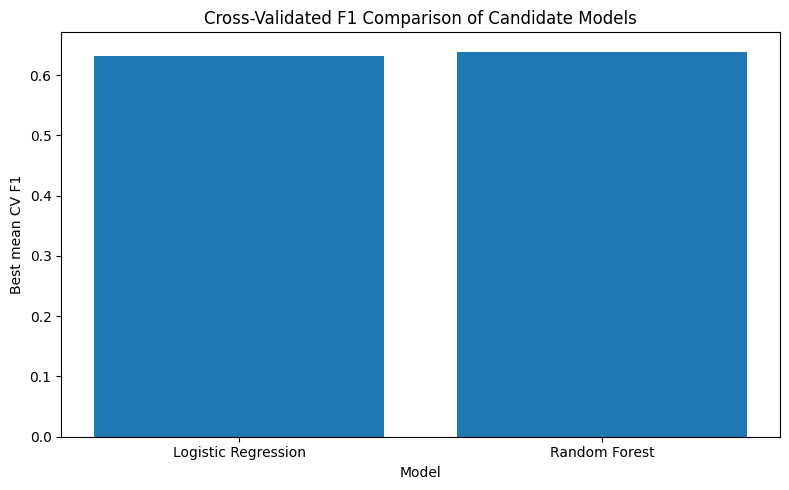

In [9]:
# ============================================================
# Cross-validation and hyperparameter tuning
# ============================================================

# Define the cross-validation splitter and the evaluation metrics used during tuning.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
}

# Search a compact but meaningful grid for logistic regression regularization and class weighting.
lr_param_grid = {
    "classifier__C": np.logspace(-2, 2, 7),
    "classifier__class_weight": [None, "balanced"],
}

# Search a bounded random-forest parameter space that balances robustness and runtime.
rf_param_distributions = {
    "classifier__n_estimators": [200, 300, 400, 500, 600],
    "classifier__max_depth": [None, 6, 10, 14, 18],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", 0.5, 0.75],
    "classifier__class_weight": [None, "balanced"],
}

# Tune logistic regression exhaustively across the chosen grid.
lr_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
)

# Tune random forest with randomized search to cover a broader space efficiently.
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=25,
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    return_train_score=False,
)

print("Running Logistic Regression grid search...")
# Fit both search objects on the training partition only.
lr_search.fit(X_train, y_train)

print("Running Random Forest randomized search...")
rf_search.fit(X_train, y_train)

def summarize_cv_search(search_obj, model_name):
    results = pd.DataFrame(search_obj.cv_results_)
    summary = {
        "model_name": model_name,
        "best_params": json.dumps(search_obj.best_params_),
        "best_mean_cv_precision": round(float(results.loc[search_obj.best_index_, "mean_test_precision"]), 4),
        "best_mean_cv_recall": round(float(results.loc[search_obj.best_index_, "mean_test_recall"]), 4),
        "best_mean_cv_f1": round(float(results.loc[search_obj.best_index_, "mean_test_f1"]), 4),
        "best_mean_cv_roc_auc": round(float(results.loc[search_obj.best_index_, "mean_test_roc_auc"]), 4),
        "best_mean_cv_balanced_accuracy": round(float(results.loc[search_obj.best_index_, "mean_test_balanced_accuracy"]), 4),
        "best_std_cv_f1": round(float(results.loc[search_obj.best_index_, "std_test_f1"]), 4),
        "best_rank_f1": int(results.loc[search_obj.best_index_, "rank_test_f1"]),
    }
    return summary

cv_summary = pd.DataFrame(
    [
        summarize_cv_search(lr_search, "Logistic Regression"),
        summarize_cv_search(rf_search, "Random Forest"),
    ]
)

display(cv_summary)
cv_summary.to_csv(PROJECT_ROOT / "exports" / "metrics" / "telco_cross_validation_summary.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(cv_summary["model_name"], cv_summary["best_mean_cv_f1"])
plt.title("Cross-Validated F1 Comparison of Candidate Models")
plt.xlabel("Model")
plt.ylabel("Best mean CV F1")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "evaluation" / "cv_model_comparison.png", dpi=300)
plt.show()


## Final model evaluation on untouched hold-out test set
This section evaluates both tuned models on the untouched test set using a balanced, decision-support-oriented metric set.

**Why this matters**
- It gives an unbiased comparison.
- It makes the error structure visible.
- It supports later threshold analysis and probability review.

**Outputs to inspect**
- Hold-out metrics comparison
- Confusion matrices
- ROC and precision-recall curves
- Probability distribution plots


,model_name,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,mean_predicted_probability,observed_test_churn_rate
1,Random Forest,0.7427,0.7548,0.5105,0.7807,0.6173,0.8363,0.6462,0.4019,0.2658
0,Logistic Regression,0.7257,0.7483,0.4901,0.7968,0.6069,0.8351,0.6183,0.4213,0.2658


,model_name,label,precision,recall,f1-score,support
0,Logistic Regression,0,0.9049,0.6999,0.7893,1033.0
1,Logistic Regression,1,0.4901,0.7968,0.6069,374.0
2,Logistic Regression,macro avg,0.6975,0.7483,0.6981,1407.0
3,Logistic Regression,weighted avg,0.7946,0.7257,0.7408,1407.0
4,Random Forest,0,0.9018,0.7289,0.8062,1033.0
5,Random Forest,1,0.5105,0.7807,0.6173,374.0
6,Random Forest,macro avg,0.7061,0.7548,0.7118,1407.0
7,Random Forest,weighted avg,0.7978,0.7427,0.7560,1407.0


,model_name,tn,fp,fn,tp
0,Logistic Regression,723,310,76,298
1,Random Forest,753,280,82,292


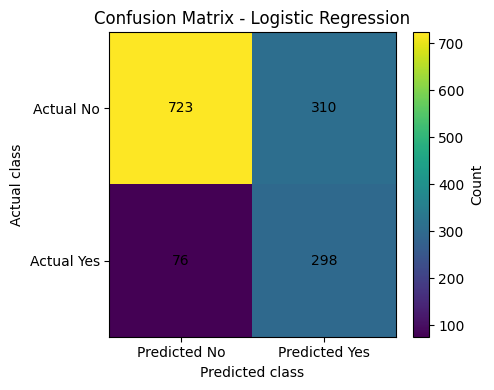

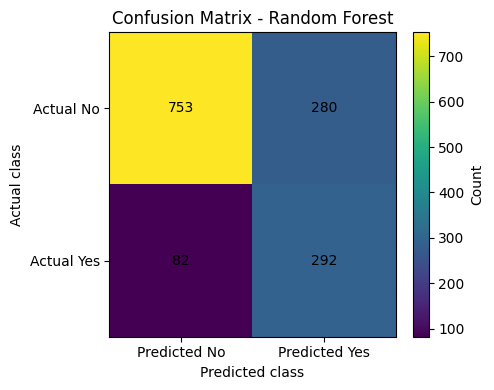

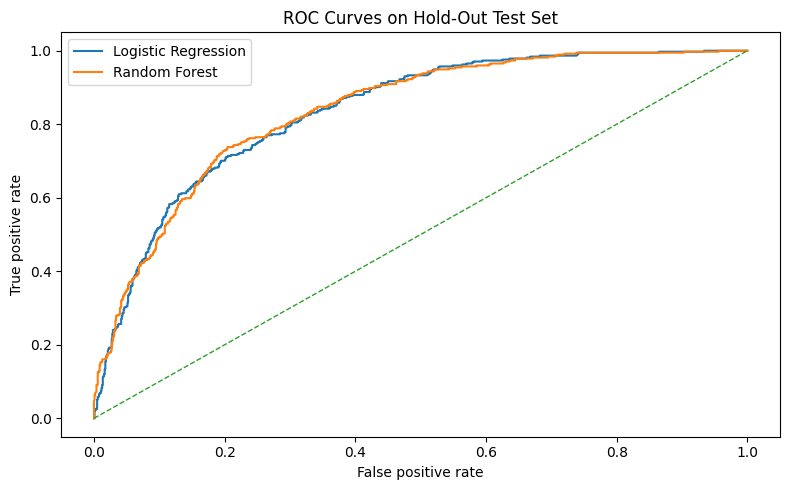

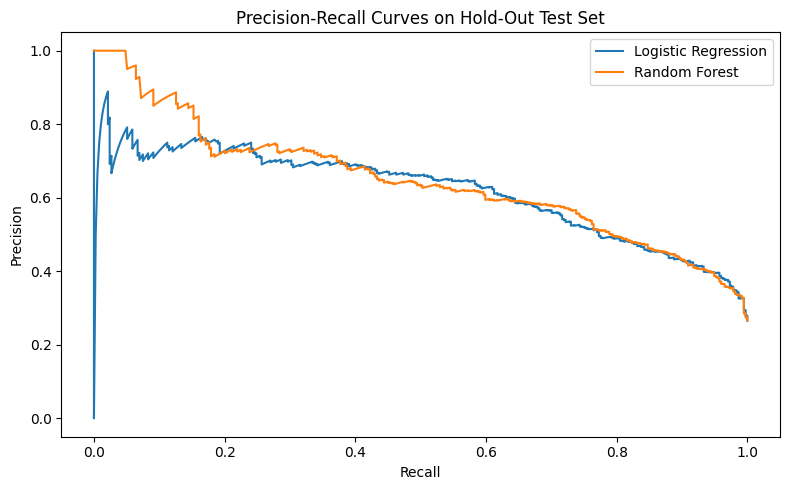

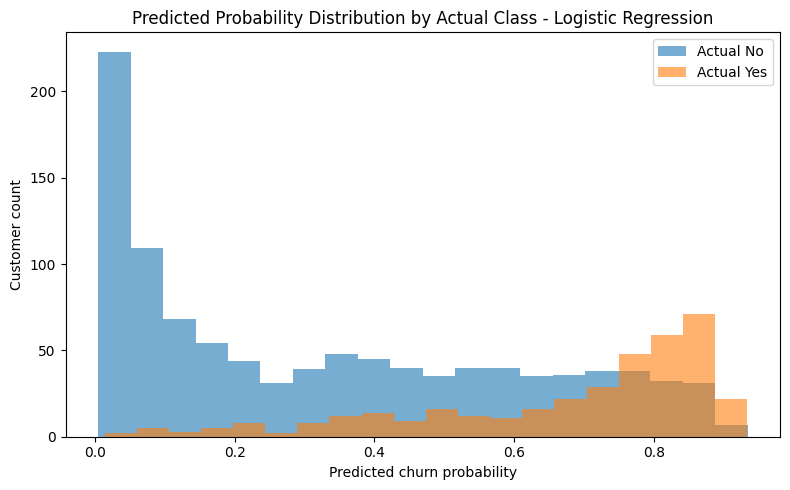

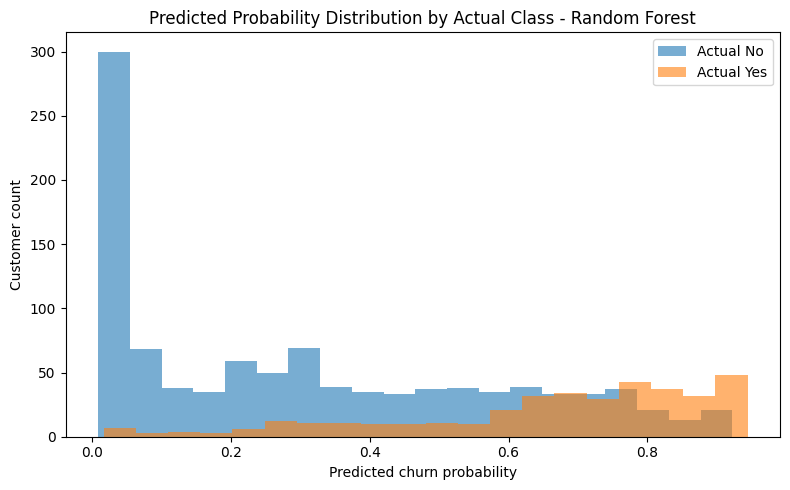

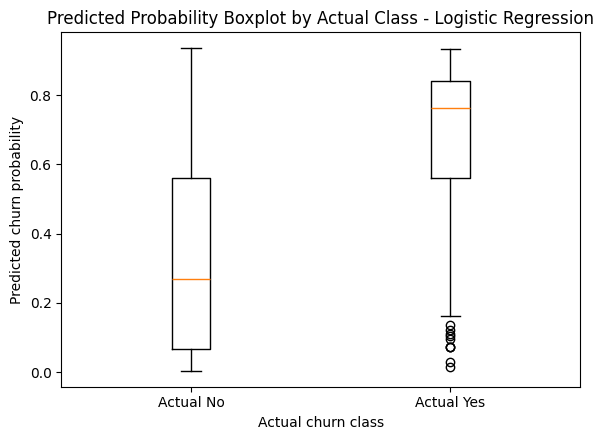

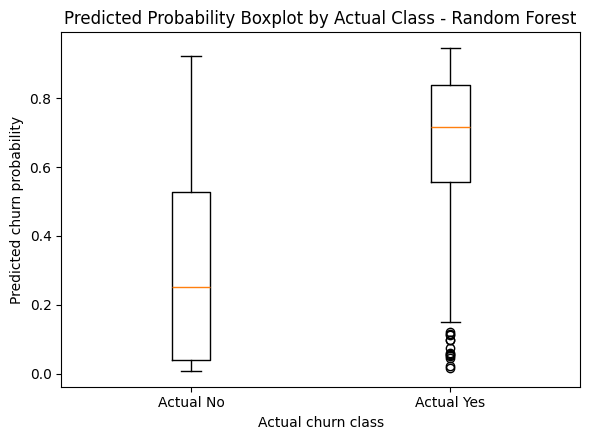

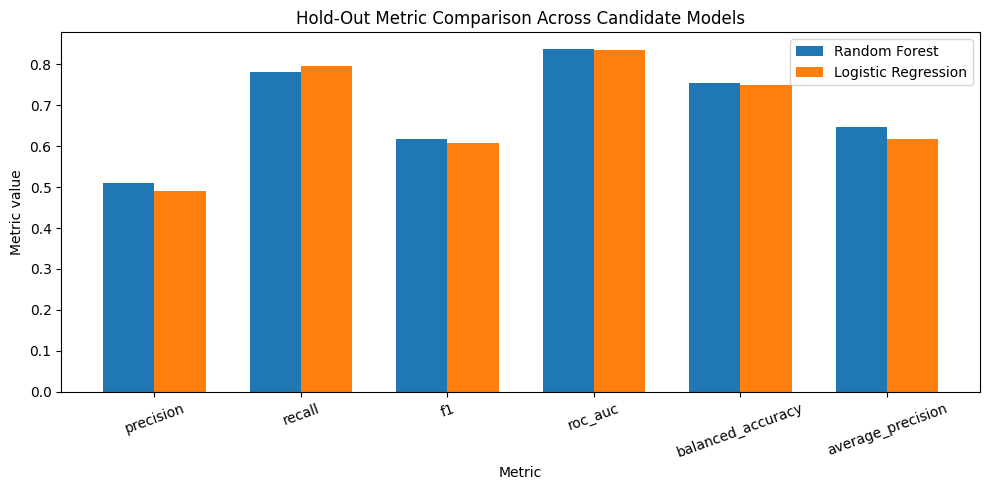

,stage,check_name,passed,details
17,post-modelling,holdout_metrics_computed,True,Hold-out metrics computed for both models.
18,post-modelling,confusion_matrices_generated,True,Confusion matrices saved for both models.
19,post-modelling,probability_outputs_available,True,Predicted probabilities stored for both models.


In [10]:
# ============================================================
# Final model evaluation on untouched hold-out test set
# ============================================================

# Pull out the tuned estimators that will now be compared on the untouched hold-out set.
best_lr = lr_search.best_estimator_
best_rf = rf_search.best_estimator_

model_registry = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
}

# Initialize containers for hold-out metrics, reports, confusion matrices, and predictions.
holdout_metrics_records = []
classification_report_records = []
confusion_matrix_records = []
holdout_predictions = {}

# Score each tuned model on the untouched test set and store both labels and probabilities.
for model_name, model in model_registry.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    holdout_predictions[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

    metrics_row = {
        "model_name": model_name,
        "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
        "balanced_accuracy": round(float(balanced_accuracy_score(y_test, y_pred)), 4),
        "precision": round(float(precision_score(y_test, y_pred, zero_division=0)), 4),
        "recall": round(float(recall_score(y_test, y_pred, zero_division=0)), 4),
        "f1": round(float(f1_score(y_test, y_pred, zero_division=0)), 4),
        "roc_auc": round(float(roc_auc_score(y_test, y_prob)), 4),
        "average_precision": round(float(average_precision_score(y_test, y_prob)), 4),
        "mean_predicted_probability": round(float(np.mean(y_prob)), 4),
        "observed_test_churn_rate": round(float(np.mean(y_test)), 4),
    }
    holdout_metrics_records.append(metrics_row)

    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    for label_name, label_metrics in report.items():
        if isinstance(label_metrics, dict):
            classification_report_records.append(
                {
                    "model_name": model_name,
                    "label": label_name,
                    "precision": round(float(label_metrics.get("precision", np.nan)), 4),
                    "recall": round(float(label_metrics.get("recall", np.nan)), 4),
                    "f1-score": round(float(label_metrics.get("f1-score", np.nan)), 4),
                    "support": float(label_metrics.get("support", np.nan)),
                }
            )

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    confusion_matrix_records.append(
        {
            "model_name": model_name,
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
        }
    )

# Convert the collected evaluation outputs into exportable DataFrames.
holdout_metrics_df = pd.DataFrame(holdout_metrics_records).sort_values(by="f1", ascending=False)
classification_report_df = pd.DataFrame(classification_report_records)
confusion_matrix_df = pd.DataFrame(confusion_matrix_records)

display(holdout_metrics_df)
display(classification_report_df.head(20))
display(confusion_matrix_df)

holdout_metrics_df.to_csv(PROJECT_ROOT / "exports" / "metrics" / "telco_holdout_metrics_comparison.csv", index=False)
classification_report_df.to_csv(PROJECT_ROOT / "exports" / "metrics" / "telco_classification_report_summary.csv", index=False)
confusion_matrix_df.to_csv(PROJECT_ROOT / "exports" / "metrics" / "telco_confusion_matrix_counts.csv", index=False)

for model_name, preds in holdout_predictions.items():
    cm = confusion_matrix(y_test, preds["y_pred"])
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, aspect="auto")
    plt.colorbar(label="Count")
    plt.xticks([0, 1], ["Predicted No", "Predicted Yes"])
    plt.yticks([0, 1], ["Actual No", "Actual Yes"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(
        PROJECT_ROOT / "figures" / "evaluation" / f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png",
        dpi=300
    )
    plt.show()

# Plot comparative ROC performance on the hold-out set.
plt.figure(figsize=(8, 5))
for model_name, preds in holdout_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_prob"])
    plt.plot(fpr, tpr, label=model_name)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("ROC Curves on Hold-Out Test Set")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "evaluation" / "holdout_roc_curves.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
for model_name, preds in holdout_predictions.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, preds["y_prob"])
    plt.plot(recall_vals, precision_vals, label=model_name)
plt.title("Precision-Recall Curves on Hold-Out Test Set")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "evaluation" / "holdout_precision_recall_curves.png", dpi=300)
plt.show()

for model_name, preds in holdout_predictions.items():
    plt.figure(figsize=(8, 5))
    plt.hist(preds["y_prob"][y_test.values == 0], bins=20, alpha=0.6, label="Actual No")
    plt.hist(preds["y_prob"][y_test.values == 1], bins=20, alpha=0.6, label="Actual Yes")
    plt.title(f"Predicted Probability Distribution by Actual Class - {model_name}")
    plt.xlabel("Predicted churn probability")
    plt.ylabel("Customer count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        PROJECT_ROOT / "figures" / "probability" / f"probability_distribution_by_actual_class_{model_name.lower().replace(' ', '_')}.png",
        dpi=300
    )
    plt.show()

for model_name, preds in holdout_predictions.items():
    plt.figure(figsize=(6, 4.5))
    data = [
        preds["y_prob"][y_test.values == 0],
        preds["y_prob"][y_test.values == 1],
    ]
    plt.boxplot(data, labels=["Actual No", "Actual Yes"])
    plt.title(f"Predicted Probability Boxplot by Actual Class - {model_name}")
    plt.xlabel("Actual churn class")
    plt.ylabel("Predicted churn probability")
    plt.tight_layout()
    plt.savefig(
        PROJECT_ROOT / "figures" / "probability" / f"probability_boxplot_by_actual_class_{model_name.lower().replace(' ', '_')}.png",
        dpi=300
    )
    plt.show()

metric_cols_to_plot = ["precision", "recall", "f1", "roc_auc", "balanced_accuracy", "average_precision"]
x = np.arange(len(metric_cols_to_plot))
width = 0.35

plt.figure(figsize=(10, 5))
for idx, model_name in enumerate(holdout_metrics_df["model_name"]):
    vals = holdout_metrics_df.loc[holdout_metrics_df["model_name"] == model_name, metric_cols_to_plot].iloc[0].values.astype(float)
    plt.bar(x + idx * width, vals, width=width, label=model_name)
plt.xticks(x + width / 2, metric_cols_to_plot, rotation=20)
plt.title("Hold-Out Metric Comparison Across Candidate Models")
plt.xlabel("Metric")
plt.ylabel("Metric value")
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "evaluation" / "holdout_metric_comparison.png", dpi=300)
plt.show()

add_quality_gate("post-modelling", "holdout_metrics_computed", True, "Hold-out metrics computed for both models.")
add_quality_gate("post-modelling", "confusion_matrices_generated", True, "Confusion matrices saved for both models.")
add_quality_gate("post-modelling", "probability_outputs_available", True, "Predicted probabilities stored for both models.")
display(pd.DataFrame(quality_gate_records)[pd.DataFrame(quality_gate_records)["stage"] == "post-modelling"])


## Threshold analysis
This section evaluates how classification behaviour changes across thresholds instead of stopping at the default 0.50 cut-off.

**Why this matters**
- It makes the business trade-off visible.
- It shows how false positives and false negatives change.
- It supports transparent decision-support interpretation.

**Outputs to inspect**
- Threshold summary table
- Threshold performance plots


,model_name,threshold,precision,recall,f1,specificity,false_positive_rate,flagged_case_count,tp,fp,fn,tn
0,Logistic Regression,0.10,0.3446,0.9840,0.5104,0.3224,0.6776,1068,368,700,6,333
1,Logistic Regression,0.15,0.3684,0.9733,0.5345,0.3959,0.6041,988,364,624,10,409
2,Logistic Regression,0.20,0.3864,0.9599,0.5510,0.4482,0.5518,929,359,570,15,463
3,Logistic Regression,0.25,0.3982,0.9358,0.5587,0.4879,0.5121,879,350,529,24,504
4,Logistic Regression,0.30,0.4148,0.9305,0.5738,0.5247,0.4753,839,348,491,26,542
5,Logistic Regression,0.35,0.4282,0.9011,0.5805,0.5644,0.4356,787,337,450,37,583
6,Logistic Regression,0.40,0.4521,0.8717,0.5954,0.6176,0.3824,721,326,395,48,638
7,Logistic Regression,0.45,0.4698,0.8316,0.6004,0.6602,0.3398,662,311,351,63,682
8,Logistic Regression,0.50,0.4901,0.7968,0.6069,0.6999,0.3001,608,298,310,76,723
9,Logistic Regression,0.55,0.5162,0.7647,0.6164,0.7406,0.2594,554,286,268,88,765


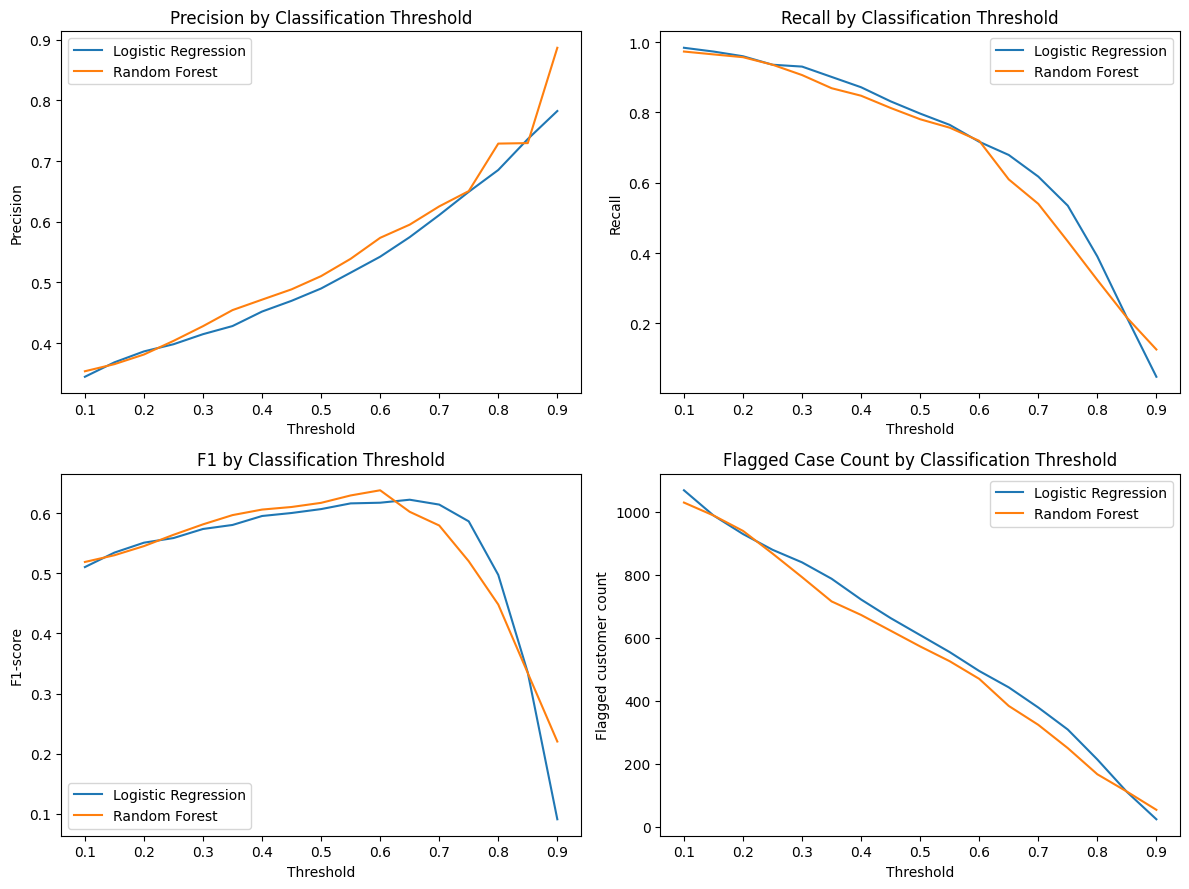

In [11]:
# ============================================================
# Threshold analysis
# ============================================================

# Evaluate a grid of classification thresholds to show precision-recall trade-offs.
threshold_grid = np.round(np.arange(0.10, 0.91, 0.05), 2)
threshold_records = []

# Recompute predictions at each threshold for every model and record the resulting confusion counts.
for model_name, preds in holdout_predictions.items():
    y_prob = preds["y_prob"]
    for threshold in threshold_grid:
        y_pred_t = (y_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

        precision_t = precision_score(y_test, y_pred_t, zero_division=0)
        recall_t = recall_score(y_test, y_pred_t, zero_division=0)
        f1_t = f1_score(y_test, y_pred_t, zero_division=0)
        specificity_t = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        fpr_t = fp / (fp + tn) if (fp + tn) > 0 else np.nan

        threshold_records.append(
            {
                "model_name": model_name,
                "threshold": float(threshold),
                "precision": round(float(precision_t), 4),
                "recall": round(float(recall_t), 4),
                "f1": round(float(f1_t), 4),
                "specificity": round(float(specificity_t), 4),
                "false_positive_rate": round(float(fpr_t), 4),
                "flagged_case_count": int(y_pred_t.sum()),
                "tp": int(tp),
                "fp": int(fp),
                "fn": int(fn),
                "tn": int(tn),
            }
        )

# Summarize the threshold analysis and export it for dashboard or report use.
threshold_df = pd.DataFrame(threshold_records)
display(threshold_df.head(20))
threshold_df.to_csv(PROJECT_ROOT / "exports" / "metrics" / "telco_threshold_analysis_summary.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for model_name in threshold_df["model_name"].unique():
    temp = threshold_df[threshold_df["model_name"] == model_name]
    axes[0, 0].plot(temp["threshold"], temp["precision"], label=model_name)
    axes[0, 1].plot(temp["threshold"], temp["recall"], label=model_name)
    axes[1, 0].plot(temp["threshold"], temp["f1"], label=model_name)
    axes[1, 1].plot(temp["threshold"], temp["flagged_case_count"], label=model_name)

axes[0, 0].set_title("Precision by Classification Threshold")
axes[0, 0].set_xlabel("Threshold")
axes[0, 0].set_ylabel("Precision")

axes[0, 1].set_title("Recall by Classification Threshold")
axes[0, 1].set_xlabel("Threshold")
axes[0, 1].set_ylabel("Recall")

axes[1, 0].set_title("F1 by Classification Threshold")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].set_ylabel("F1-score")

axes[1, 1].set_title("Flagged Case Count by Classification Threshold")
axes[1, 1].set_xlabel("Threshold")
axes[1, 1].set_ylabel("Flagged customer count")

for ax in axes.ravel():
    ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "evaluation" / "threshold_tradeoff_plots.png", dpi=300)
plt.show()


## Final model selection rule and justification
The final model is chosen using a neutral hold-out performance rule rather than a model-specific preference.

**Selection rule**
The chosen model should provide the strongest overall hold-out performance across:
- precision,
- recall,
- F1,
- ROC-AUC,
- balanced accuracy,
- average precision,
- confusion-matrix behaviour.

**Decision principle**
The notebook applies the same scoring and ranking logic to both models and does not hard-code any model preference.


,model_name,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,mean_predicted_probability,observed_test_churn_rate,tn,fp,fn,tp,decision_support_score,selected_final_model
0,Random Forest,0.7427,0.7548,0.5105,0.7807,0.6173,0.8363,0.6462,0.4019,0.2658,753,280,82,292,0.6910,Yes
1,Logistic Regression,0.7257,0.7483,0.4901,0.7968,0.6069,0.8351,0.6183,0.4213,0.2658,723,310,76,298,0.6826,No


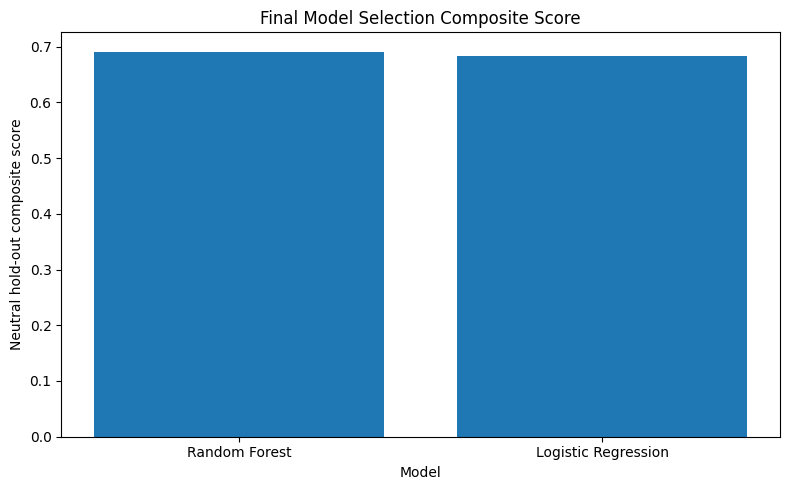

Selected final model: Random Forest
Model selection justification:
- Precision: 0.5105
- Recall: 0.7807
- F1: 0.6173
- ROC-AUC: 0.8363
- Balanced accuracy: 0.7548
- Average precision: 0.6462
- Composite score: 0.691


In [12]:
# ============================================================
# Final model selection rule and justification
# ============================================================

# Merge the hold-out metric table with confusion-matrix counts so the selection summary is self-contained.
selection_df = holdout_metrics_df.merge(
    confusion_matrix_df,
    on="model_name",
    how="left",
)

# Build a neutral composite score using only hold-out performance metrics.
# All included metrics are on a 0-1 scale, so equal weighting keeps the rule model-agnostic.
selection_metric_columns = [
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "balanced_accuracy",
    "average_precision",
]
selection_df["decision_support_score"] = selection_df[selection_metric_columns].mean(axis=1).round(4)

# Rank models from strongest to weakest using the neutral composite score,
# then use core discrimination metrics as deterministic secondary sort keys.
selection_df = selection_df.sort_values(
    by=["decision_support_score", "f1", "roc_auc", "balanced_accuracy", "average_precision", "precision", "recall"],
    ascending=[False, False, False, False, False, False, False],
).reset_index(drop=True)

# Select the top-ranked model directly with no model-specific override logic.
selected_model_name = selection_df.loc[0, "model_name"]
selected_model = model_registry[selected_model_name]

selection_df["selected_final_model"] = selection_df["model_name"].eq(selected_model_name).map({True: "Yes", False: "No"})
display(selection_df)

selection_df.to_csv(PROJECT_ROOT / "exports" / "metrics" / "telco_model_selection_summary.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(selection_df["model_name"], selection_df["decision_support_score"])
plt.title("Final Model Selection Composite Score")
plt.xlabel("Model")
plt.ylabel("Neutral hold-out composite score")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "evaluation" / "final_model_selection_composite_score.png", dpi=300)
plt.show()

selected_row = selection_df.loc[selection_df["model_name"] == selected_model_name].iloc[0]
print("Selected final model:", selected_model_name)
print("Model selection justification:")
print(
    f"- Precision: {selected_row['precision']}\n"
    f"- Recall: {selected_row['recall']}\n"
    f"- F1: {selected_row['f1']}\n"
    f"- ROC-AUC: {selected_row['roc_auc']}\n"
    f"- Balanced accuracy: {selected_row['balanced_accuracy']}\n"
    f"- Average precision: {selected_row['average_precision']}\n"
    f"- Composite score: {selected_row['decision_support_score']}"
)


## Churn-risk score creation
This section fits the selected final model to the full cleaned dataset, produces customer-level probabilities, converts them to a transparent 0–100 score, and assigns stable four-band risk categories.

**Why this matters**
- It turns model output into an action-friendly business signal.
- It keeps the raw probability visible for traceability.
- It avoids arbitrary nonlinear score transformations.

**Band logic**
- Low: 0–29
- Moderate: 30–59
- High: 60–79
- Critical: 80–100


,risk_band,score_range,operational_meaning
0,Low,0-29,Monitor; usually not immediate action.
1,Moderate,30-59,Watchlist; consider contextual review.
2,High,60-79,Priority review candidates for retention outre...
3,Critical,80-100,Highest priority cases for attention subject t...


,risk_band,customer_count,percentage
0,Low,3119,44.35
1,Moderate,1607,22.85
2,High,1432,20.36
3,Critical,874,12.43


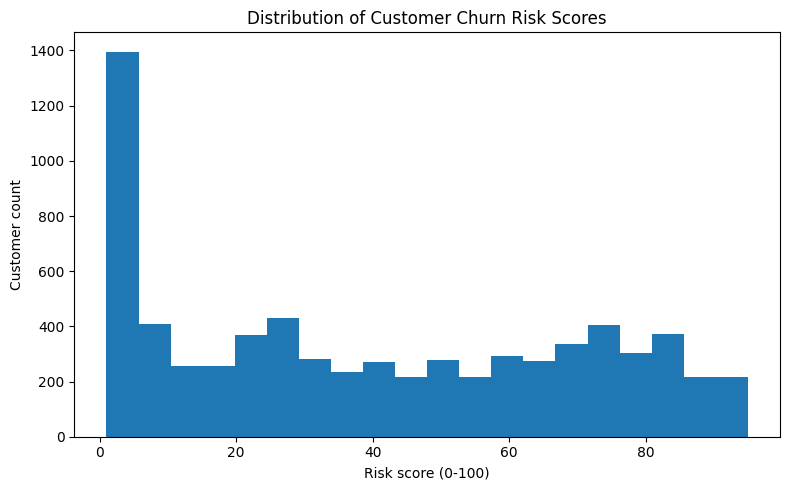

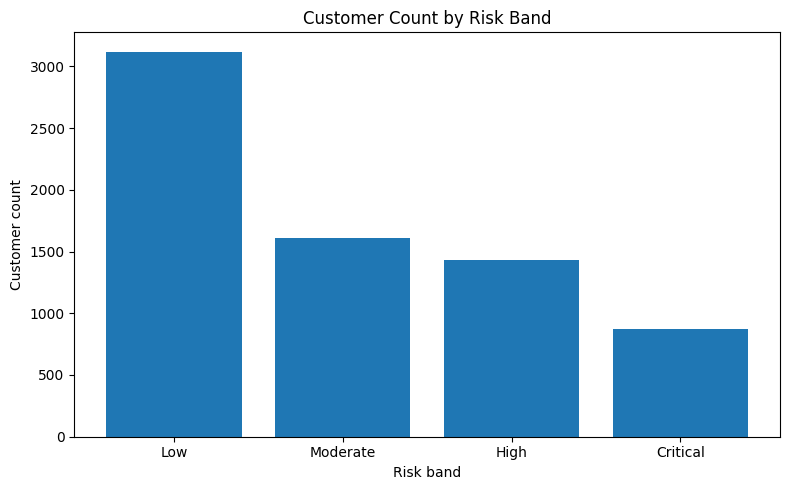

In [13]:
# ============================================================
# Churn-risk score creation
# ============================================================

# Fit the selected final model on the full cleaned dataset so all customer-level
# scored outputs are generated from one consistent final estimator.
final_model = clone(selected_model)
final_model.fit(X, y)

# Generate customer-level churn probabilities and binary predictions at the default threshold.
full_predicted_probability = final_model.predict_proba(X)[:, 1]
full_predicted_label = (full_predicted_probability >= 0.50).astype(int)

# Translate the 0-100 risk score into clear managerial risk bands.
def assign_risk_band(score):
    if 0 <= score <= 29:
        return "Low"
    elif 30 <= score <= 59:
        return "Moderate"
    elif 60 <= score <= 79:
        return "High"
    elif 80 <= score <= 100:
        return "Critical"
    else:
        return "Out of Range"

# Attach the final probabilities, 0-100 risk scores, predicted labels, and selected model metadata to each record.
clean_df["predicted_probability"] = np.round(full_predicted_probability, 4)
clean_df["risk_score_0_100"] = np.rint(clean_df["predicted_probability"] * 100).astype(int)
clean_df["risk_band"] = clean_df["risk_score_0_100"].apply(assign_risk_band)
clean_df["predicted_label_threshold_0_50"] = full_predicted_label.astype(int)
clean_df["selected_model_name"] = selected_model_name

# Define and export the business meaning of each risk band.
risk_band_definition = pd.DataFrame(
    [
        {"risk_band": "Low", "score_range": "0-29", "operational_meaning": "Monitor; usually not immediate action."},
        {"risk_band": "Moderate", "score_range": "30-59", "operational_meaning": "Watchlist; consider contextual review."},
        {"risk_band": "High", "score_range": "60-79", "operational_meaning": "Priority review candidates for retention outreach."},
        {"risk_band": "Critical", "score_range": "80-100", "operational_meaning": "Highest priority cases for attention subject to capacity."},
    ]
)
risk_band_definition.to_csv(PROJECT_ROOT / "exports" / "tables" / "telco_risk_band_definition_table.csv", index=False)

# Summarize how customers are distributed across the final risk bands.
risk_band_summary = (
    clean_df["risk_band"]
    .value_counts(dropna=False)
    .rename_axis("risk_band")
    .reset_index(name="customer_count")
)
risk_band_summary["percentage"] = (risk_band_summary["customer_count"] / len(clean_df) * 100).round(2)
risk_band_summary.to_csv(PROJECT_ROOT / "exports" / "dashboard" / "telco_risk_band_summary.csv", index=False)

display(risk_band_definition)
display(risk_band_summary)

plt.figure(figsize=(8, 5))
plt.hist(clean_df["risk_score_0_100"], bins=20)
plt.title("Distribution of Customer Churn Risk Scores")
plt.xlabel("Risk score (0-100)")
plt.ylabel("Customer count")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "scoring" / "risk_score_distribution.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(risk_band_summary["risk_band"], risk_band_summary["customer_count"])
plt.title("Customer Count by Risk Band")
plt.xlabel("Risk band")
plt.ylabel("Customer count")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "scoring" / "risk_band_customer_count.png", dpi=300)
plt.show()

clean_df.to_csv(PROJECT_ROOT / "data" / "processed" / "telco_scored_dataset_with_risk_outputs.csv", index=False)

add_quality_gate("post-scoring", "risk_scores_created", True, "Predicted probabilities and 0-100 risk scores created.")
add_quality_gate("post-scoring", "risk_bands_created", True, "Risk bands assigned to all customers.")
add_quality_gate("post-scoring", "scored_dataset_exported", True, PROJECT_ROOT / "data" / "processed" / "telco_scored_dataset_with_risk_outputs.csv")


## Explainability outputs
This section produces both formal explainability outputs and light manager-friendly cue fields for dashboard use.

**Why this matters**
- It reduces black-box behaviour in the manager-facing artifact.
- It supports explanation without making causal claims.
- It ties model outputs back to understandable business attributes.


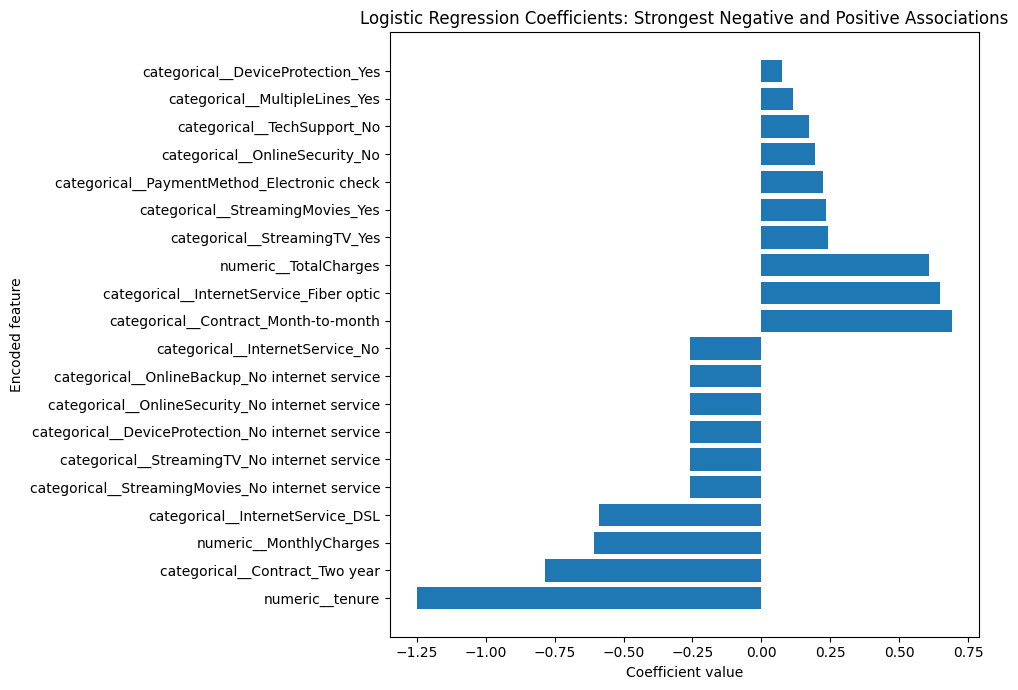

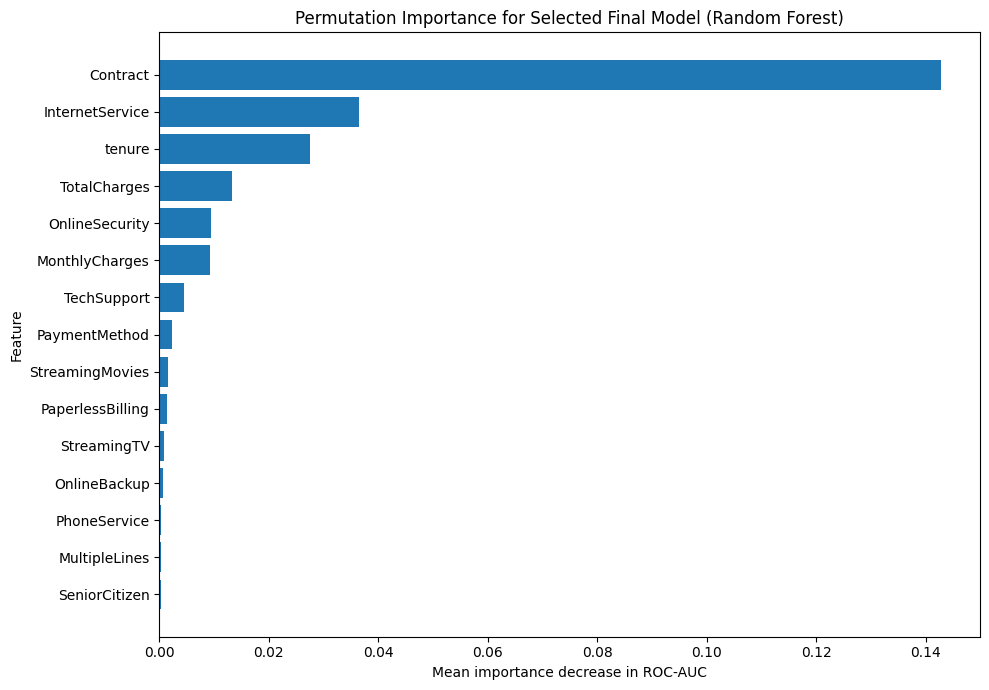

,feature_name,coefficient,association_direction
0,categorical__Contract_Month-to-month,0.692161,Associated with higher predicted churn risk
1,categorical__InternetService_Fiber optic,0.648090,Associated with higher predicted churn risk
2,numeric__TotalCharges,0.607905,Associated with higher predicted churn risk
3,categorical__StreamingTV_Yes,0.242722,Associated with higher predicted churn risk
4,categorical__StreamingMovies_Yes,0.235556,Associated with higher predicted churn risk
5,categorical__PaymentMethod_Electronic check,0.225095,Associated with higher predicted churn risk
6,categorical__OnlineSecurity_No,0.193172,Associated with higher predicted churn risk
7,categorical__TechSupport_No,0.171469,Associated with higher predicted churn risk
8,categorical__MultipleLines_Yes,0.115741,Associated with higher predicted churn risk
9,categorical__DeviceProtection_Yes,0.075799,Associated with higher predicted churn risk


,feature_name,importance_mean,importance_std,interpretation_note
0,Contract,0.142806,0.015840,Higher value means the model relied more on th...
1,InternetService,0.036417,0.005840,Higher value means the model relied more on th...
2,tenure,0.027518,0.004397,Higher value means the model relied more on th...
3,TotalCharges,0.013190,0.003005,Higher value means the model relied more on th...
4,OnlineSecurity,0.009504,0.002421,Higher value means the model relied more on th...
5,MonthlyCharges,0.009170,0.004089,Higher value means the model relied more on th...
6,TechSupport,0.004468,0.001029,Higher value means the model relied more on th...
7,PaymentMethod,0.002262,0.000818,Higher value means the model relied more on th...
8,StreamingMovies,0.001648,0.000580,Higher value means the model relied more on th...
9,PaperlessBilling,0.001386,0.000828,Higher value means the model relied more on th...


,cue_label,rule_basis
0,Month-to-month contract,Contract == 'Month-to-month'
1,Short tenure,tenure <= 12
2,Fiber optic service,InternetService == 'Fiber optic'
3,Electronic check payment,PaymentMethod == 'Electronic check'
4,Higher monthly charges,MonthlyCharges >= 89.86
5,No online security,OnlineSecurity != 'Yes'
6,No tech support,TechSupport != 'Yes'
7,Paperless billing,PaperlessBilling == 'Yes'
8,No dependents,Dependents == 'No'


In [14]:
# ============================================================
# Explainability outputs
# ============================================================

# Refit the selected final model on the training data so leakage-safe permutation importance uses only training-side fitting.
explainability_model = clone(selected_model)
explainability_model.fit(X_train, y_train)

# Refit logistic regression on the training data so coefficient-based explanations stay aligned with the tuned pipeline.
fitted_lr_for_explain = clone(best_lr)
fitted_lr_for_explain.fit(X_train, y_train)

# Extract the fitted preprocessing and classifier objects needed for coefficient interpretation.
lr_preprocessor_fitted = fitted_lr_for_explain.named_steps["preprocessor"]
lr_classifier_fitted = fitted_lr_for_explain.named_steps["classifier"]
lr_feature_names = lr_preprocessor_fitted.get_feature_names_out()
lr_coefficients = lr_classifier_fitted.coef_.ravel()

# Pair each transformed feature name with its logistic regression coefficient.
lr_coef_df = pd.DataFrame(
    {
        "feature_name": lr_feature_names,
        "coefficient": lr_coefficients,
    }
).sort_values(by="coefficient", ascending=False).reset_index(drop=True)

lr_coef_df["association_direction"] = np.where(
    lr_coef_df["coefficient"] >= 0,
    "Associated with higher predicted churn risk",
    "Associated with lower predicted churn risk",
)

lr_coef_df.to_csv(PROJECT_ROOT / "exports" / "metrics" / "telco_logistic_regression_coefficients.csv", index=False)

top_positive = lr_coef_df.head(10).copy()
top_negative = lr_coef_df.tail(10).sort_values(by="coefficient", ascending=True).copy()
coef_plot_df = pd.concat([top_negative, top_positive], axis=0).reset_index(drop=True)

plt.figure(figsize=(10, 7))
plt.barh(coef_plot_df["feature_name"], coef_plot_df["coefficient"])
plt.title("Logistic Regression Coefficients: Strongest Negative and Positive Associations")
plt.xlabel("Coefficient value")
plt.ylabel("Encoded feature")
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "figures" / "explainability" / "logistic_regression_coefficients_top_positive_negative.png",
    dpi=300,
)
plt.show()

# Compute permutation importance on the full pipeline using the original test-set columns.
perm_result = permutation_importance(
    explainability_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=-1,
)

# Because permutation importance was run on the full pipeline, use the original X_test column names here.
selected_feature_names = X_test.columns.tolist()
perm_df = pd.DataFrame(
    {
        "feature_name": selected_feature_names,
        "importance_mean": perm_result.importances_mean,
        "importance_std": perm_result.importances_std,
    }
).sort_values(by="importance_mean", ascending=False).reset_index(drop=True)

perm_df["interpretation_note"] = "Higher value means the model relied more on this original input feature for discrimination on the hold-out test set."
perm_df.to_csv(PROJECT_ROOT / "exports" / "metrics" / "telco_final_model_permutation_importance.csv", index=False)

top_perm = perm_df.head(15).sort_values(by="importance_mean", ascending=True)
plt.figure(figsize=(10, 7))
plt.barh(top_perm["feature_name"], top_perm["importance_mean"])
plt.title(f"Permutation Importance for Selected Final Model ({selected_model_name})")
plt.xlabel("Mean importance decrease in ROC-AUC")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "figures" / "explainability" / "selected_model_permutation_importance.png",
    dpi=300,
)
plt.show()

# Create a simple rules-based explanation layer that generates lightweight customer cues for the dashboard.
high_monthly_charge_threshold = clean_df["MonthlyCharges"].quantile(0.75)

cue_reference_table = pd.DataFrame(
    [
        {"cue_label": "Month-to-month contract", "rule_basis": "Contract == 'Month-to-month'"},
        {"cue_label": "Short tenure", "rule_basis": "tenure <= 12"},
        {"cue_label": "Fiber optic service", "rule_basis": "InternetService == 'Fiber optic'"},
        {"cue_label": "Electronic check payment", "rule_basis": "PaymentMethod == 'Electronic check'"},
        {"cue_label": "Higher monthly charges", "rule_basis": f"MonthlyCharges >= {round(float(high_monthly_charge_threshold), 2)}"},
        {"cue_label": "No online security", "rule_basis": "OnlineSecurity != 'Yes'"},
        {"cue_label": "No tech support", "rule_basis": "TechSupport != 'Yes'"},
        {"cue_label": "Paperless billing", "rule_basis": "PaperlessBilling == 'Yes'"},
        {"cue_label": "No dependents", "rule_basis": "Dependents == 'No'"},
    ]
)
cue_reference_table.to_csv(PROJECT_ROOT / "exports" / "metrics" / "telco_explanation_cue_reference_table.csv", index=False)

# Translate selected customer characteristics into short, business-readable explanation cues.
def derive_customer_cues(row):
    cues = []
    if row["Contract"] == "Month-to-month":
        cues.append("Month-to-month contract")
    if row["tenure"] <= 12:
        cues.append("Short tenure")
    if row["InternetService"] == "Fiber optic":
        cues.append("Fiber optic service")
    if row["PaymentMethod"] == "Electronic check":
        cues.append("Electronic check payment")
    if row["MonthlyCharges"] >= high_monthly_charge_threshold:
        cues.append("Higher monthly charges")
    if row["OnlineSecurity"] != "Yes":
        cues.append("No online security")
    if row["TechSupport"] != "Yes":
        cues.append("No tech support")
    if row["PaperlessBilling"] == "Yes":
        cues.append("Paperless billing")
    if row["Dependents"] == "No":
        cues.append("No dependents")

    cues = list(dict.fromkeys(cues))
    top_1 = cues[0] if len(cues) >= 1 else "No prominent cue"
    top_2 = cues[1] if len(cues) >= 2 else "No secondary cue"

    summary_bits = [bit for bit in [top_1, top_2] if not bit.startswith("No ")]
    if len(summary_bits) == 0:
        short_summary = "No single dominant cue; review full customer profile."
    else:
        short_summary = "Associated with " + " and ".join(summary_bits).lower() + "."

    return pd.Series([top_1, top_2, short_summary])

# Apply the cue function row-wise so every customer record receives lightweight explanation fields.
clean_df[["top_risk_driver_1", "top_risk_driver_2", "risk_driver_summary_short"]] = clean_df.apply(
    derive_customer_cues,
    axis=1,
)

display(lr_coef_df.head(15))
display(perm_df.head(15))
display(cue_reference_table)

add_quality_gate("post-explainability", "logistic_coefficients_exported", True, "Logistic Regression coefficient table exported.")
add_quality_gate("post-explainability", "permutation_importance_exported", True, "Permutation importance exported for selected model.")
add_quality_gate("post-explainability", "light_dashboard_cues_created", True, "top_risk_driver_1, top_risk_driver_2, and risk_driver_summary_short created.")


## Export generation
This section builds the schema-stable dashboard handoff files and supporting exports.

**Why this matters**
- Power BI should receive clean, human-readable, stable tables.
- The dashboard should not depend on encoded model matrices.
- Exports must be explicit, documented, and traceable.


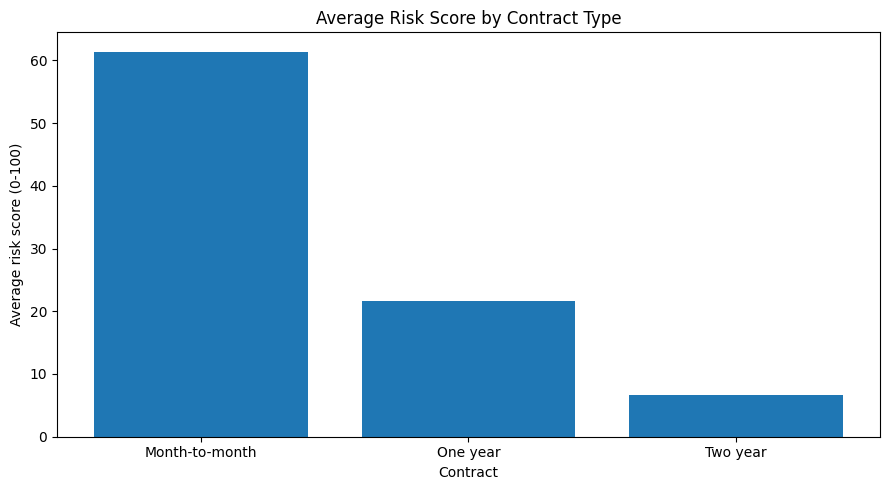

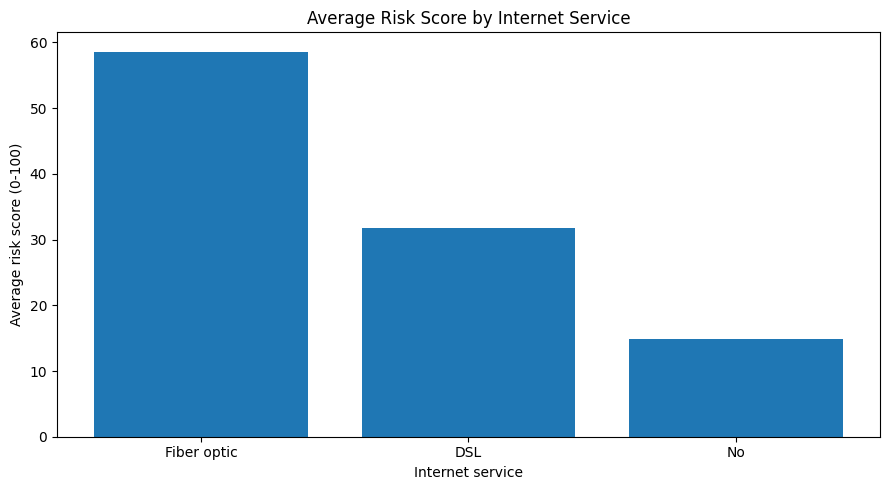

,check_name,passed
0,dashboard_export_exists,True
1,dashboard_row_count_matches_clean_df,True
2,customerID_unique,True
3,predicted_probability_numeric,True
4,risk_score_numeric,True
5,risk_band_complete,True
6,selected_model_name_present,True


,stage,check_name,passed,details
26,post-export,main_dashboard_csv_exported,True,exports\dashboard\telco_scored_customers_dashb...
27,post-export,high_risk_table_exported,True,High-risk priority table exported.
28,post-export,dashboard_data_dictionary_exported,True,Dashboard data dictionary exported.
29,post-export,export_schema_checks_completed,True,"[{'check_name': 'dashboard_export_exists', 'pa..."


In [15]:
# ============================================================
# Export generation
# ============================================================

# Specify the final dashboard schema, combining scores, business fields, derived fields, and explanation cues.
dashboard_columns = [
    "customerID",
    "actual_churn_label",
    "predicted_probability",
    "risk_score_0_100",
    "risk_band",
    "predicted_label_threshold_0_50",
    "selected_model_name",
    "dataset_partition",
] + original_business_fields + dashboard_derived_fields + [
    "top_risk_driver_1",
    "top_risk_driver_2",
    "risk_driver_summary_short",
]

# Build the main customer-level dashboard export from the scored dataset.
dashboard_df = clean_df[dashboard_columns].copy()

dashboard_export_path = PROJECT_ROOT / "exports" / "dashboard" / "telco_scored_customers_dashboard.csv"
dashboard_df.to_csv(dashboard_export_path, index=False)

# Create a priority table containing only the high- and critical-risk customers.
high_risk_priority_table = dashboard_df.loc[
    dashboard_df["risk_band"].isin(["High", "Critical"]),
    [
        "customerID",
        "actual_churn_label",
        "predicted_probability",
        "risk_score_0_100",
        "risk_band",
        "Contract",
        "InternetService",
        "PaymentMethod",
        "tenure",
        "MonthlyCharges",
        "top_risk_driver_1",
        "top_risk_driver_2",
        "risk_driver_summary_short",
    ],
].sort_values(by=["risk_score_0_100", "predicted_probability"], ascending=[False, False])

high_risk_priority_table.to_csv(
    PROJECT_ROOT / "exports" / "dashboard" / "telco_high_risk_priority_table.csv",
    index=False,
)

dictionary_rows = []
for col in dashboard_df.columns:
    dictionary_rows.append(
        {
            "column_name": col,
            "dtype": str(dashboard_df[col].dtype),
            "description": {
                "customerID": "Customer identifier retained for dashboard traceability.",
                "actual_churn_label": "Observed churn status from the dataset.",
                "predicted_probability": "Selected model estimated probability of churn.",
                "risk_score_0_100": "Rounded 0-100 version of predicted probability.",
                "risk_band": "Operational risk band derived from risk score.",
                "predicted_label_threshold_0_50": "Binary label at probability threshold 0.50.",
                "selected_model_name": "Name of the final selected model used to generate exported scores.",
                "dataset_partition": "Train/test/full traceability partition flag.",
                "top_risk_driver_1": "Primary light explanation cue associated with higher predicted churn risk.",
                "top_risk_driver_2": "Secondary light explanation cue associated with higher predicted churn risk.",
                "risk_driver_summary_short": "Concise dashboard-friendly association summary.",
            }.get(col, "Business field preserved in human-readable form for segmentation, filtering, or drill-down."),
        }
    )

dashboard_data_dictionary = pd.DataFrame(dictionary_rows)
dashboard_data_dictionary.to_csv(
    PROJECT_ROOT / "exports" / "dashboard" / "telco_dashboard_data_dictionary.csv",
    index=False,
)

contract_risk_summary = (
    dashboard_df.groupby("Contract")["risk_score_0_100"]
    .mean()
    .reset_index(name="average_risk_score")
    .sort_values(by="average_risk_score", ascending=False)
)
plt.figure(figsize=(9, 5))
plt.bar(contract_risk_summary["Contract"], contract_risk_summary["average_risk_score"])
plt.title("Average Risk Score by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Average risk score (0-100)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "dashboard_handoff" / "average_risk_score_by_contract.png", dpi=300)
plt.show()

internet_risk_summary = (
    dashboard_df.groupby("InternetService")["risk_score_0_100"]
    .mean()
    .reset_index(name="average_risk_score")
    .sort_values(by="average_risk_score", ascending=False)
)
plt.figure(figsize=(9, 5))
plt.bar(internet_risk_summary["InternetService"], internet_risk_summary["average_risk_score"])
plt.title("Average Risk Score by Internet Service")
plt.xlabel("Internet service")
plt.ylabel("Average risk score (0-100)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "dashboard_handoff" / "average_risk_score_by_internet_service.png", dpi=300)
plt.show()

export_schema_check = pd.DataFrame(
    [
        {"check_name": "dashboard_export_exists", "passed": dashboard_export_path.exists()},
        {"check_name": "dashboard_row_count_matches_clean_df", "passed": len(dashboard_df) == len(clean_df)},
        {"check_name": "customerID_unique", "passed": dashboard_df["customerID"].nunique() == len(dashboard_df)},
        {"check_name": "predicted_probability_numeric", "passed": pd.api.types.is_numeric_dtype(dashboard_df["predicted_probability"])},
        {"check_name": "risk_score_numeric", "passed": pd.api.types.is_numeric_dtype(dashboard_df["risk_score_0_100"])},
        {"check_name": "risk_band_complete", "passed": dashboard_df["risk_band"].isna().sum() == 0},
        {"check_name": "selected_model_name_present", "passed": dashboard_df["selected_model_name"].notna().all()},
    ]
)
export_schema_check.to_csv(PROJECT_ROOT / "exports" / "qa" / "telco_export_schema_check.csv", index=False)
display(export_schema_check)

add_quality_gate("post-export", "main_dashboard_csv_exported", dashboard_export_path.exists(), dashboard_export_path)
add_quality_gate("post-export", "high_risk_table_exported", (PROJECT_ROOT / "exports" / "dashboard" / "telco_high_risk_priority_table.csv").exists(), "High-risk priority table exported.")
add_quality_gate("post-export", "dashboard_data_dictionary_exported", (PROJECT_ROOT / "exports" / "dashboard" / "telco_dashboard_data_dictionary.csv").exists(), "Dashboard data dictionary exported.")
add_quality_gate("post-export", "export_schema_checks_completed", export_schema_check["passed"].all(), export_schema_check.to_dict(orient="records"))
display(pd.DataFrame(quality_gate_records)[pd.DataFrame(quality_gate_records)["stage"] == "post-export"])


## QA checks and completion message
This final section writes the quality-gate checklist, produces a file manifest, and prints a completion summary for the project.

**Why this matters**
- It gives a visible QA trail.
- It confirms export existence and schema stability.
- It provides a concise end-of-run status summary and dashboard handoff.


In [16]:
# ============================================================
# QA checks and completion message
# ============================================================

# Refresh the cumulative quality-gate table now that all notebook stages have completed.
quality_gate_df = pd.DataFrame(quality_gate_records)

# List the core deliverables that must exist before the notebook can declare success.
required_files = [
    PROJECT_ROOT / "data" / "processed" / "telco_cleaned_base_dataset.csv",
    PROJECT_ROOT / "exports" / "dashboard" / "telco_scored_customers_dashboard.csv",
    PROJECT_ROOT / "exports" / "dashboard" / "telco_risk_band_summary.csv",
    PROJECT_ROOT / "exports" / "dashboard" / "telco_segment_summary_by_contract.csv",
    PROJECT_ROOT / "exports" / "dashboard" / "telco_segment_summary_by_payment_method.csv",
    PROJECT_ROOT / "exports" / "dashboard" / "telco_segment_summary_by_internet_service.csv",
    PROJECT_ROOT / "exports" / "dashboard" / "telco_high_risk_priority_table.csv",
    PROJECT_ROOT / "exports" / "dashboard" / "telco_dashboard_data_dictionary.csv",
    PROJECT_ROOT / "exports" / "metrics" / "telco_cross_validation_summary.csv",
    PROJECT_ROOT / "exports" / "metrics" / "telco_holdout_metrics_comparison.csv",
    PROJECT_ROOT / "exports" / "metrics" / "telco_threshold_analysis_summary.csv",
    PROJECT_ROOT / "exports" / "metrics" / "telco_model_selection_summary.csv",
    PROJECT_ROOT / "exports" / "metrics" / "telco_logistic_regression_coefficients.csv",
    PROJECT_ROOT / "exports" / "metrics" / "telco_final_model_permutation_importance.csv",
    PROJECT_ROOT / "exports" / "metrics" / "telco_explanation_cue_reference_table.csv",
    PROJECT_ROOT / "exports" / "tables" / "telco_data_audit_summary.csv",
    PROJECT_ROOT / "exports" / "tables" / "telco_missingness_summary.csv",
    PROJECT_ROOT / "exports" / "tables" / "telco_class_balance_summary.csv",
    PROJECT_ROOT / "exports" / "tables" / "telco_feature_summary_table.csv",
    PROJECT_ROOT / "exports" / "tables" / "telco_risk_band_definition_table.csv",
    PROJECT_ROOT / "exports" / "qa" / "telco_export_schema_check.csv",
]

for req_path in required_files:
    add_quality_gate("final-qa", f"file_exists::{req_path.name}", req_path.exists(), req_path)

add_quality_gate(
    "final-qa",
    "customerID_uniqueness_check",
    dashboard_df["customerID"].nunique() == len(dashboard_df),
    f"Unique customerID count = {dashboard_df['customerID'].nunique()}, row count = {len(dashboard_df)}",
)
add_quality_gate(
    "final-qa",
    "score_probability_numeric_dtype_check",
    pd.api.types.is_numeric_dtype(dashboard_df["predicted_probability"]) and pd.api.types.is_numeric_dtype(dashboard_df["risk_score_0_100"]),
    "predicted_probability and risk_score_0_100 are numeric.",
)
add_quality_gate(
    "final-qa",
    "risk_band_count_check",
    dashboard_df["risk_band"].isna().sum() == 0,
    dashboard_df["risk_band"].value_counts().to_dict(),
)
add_quality_gate(
    "final-qa",
    "no_full_dataset_preprocessing_fit_assertion",
    True,
    "All scaling and one-hot encoding for model fitting were defined inside scikit-learn pipelines.",
)
add_quality_gate(
    "final-qa",
    "rerun_completion_note",
    True,
    "Notebook structured for Restart Kernel + Run All execution.",
)

quality_gate_df = pd.DataFrame(quality_gate_records)
quality_gate_df.to_csv(PROJECT_ROOT / "exports" / "qa" / "telco_quality_gate_checklist.csv", index=False)

file_manifest_rows = []
for root, dirs, files in os.walk(PROJECT_ROOT / "exports"):
    for file in files:
        full_path = Path(root) / file
        file_manifest_rows.append(
            {
                "relative_path": str(full_path.relative_to(PROJECT_ROOT)),
                "size_bytes": int(full_path.stat().st_size),
            }
        )
for root, dirs, files in os.walk(PROJECT_ROOT / "figures"):
    for file in files:
        full_path = Path(root) / file
        file_manifest_rows.append(
            {
                "relative_path": str(full_path.relative_to(PROJECT_ROOT)),
                "size_bytes": int(full_path.stat().st_size),
            }
        )

file_manifest_df = pd.DataFrame(file_manifest_rows).sort_values(by="relative_path").reset_index(drop=True)
file_manifest_df.to_csv(PROJECT_ROOT / "exports" / "qa" / "telco_file_manifest.csv", index=False)

# Build a path-safe run manifest for reproducibility and QA.
run_manifest = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "project_root_label": Path(PROJECT_ROOT).name or "project_root",
    "resolved_raw_dataset_path": relative_display_path(RAW_DATASET_PATH, PROJECT_ROOT),
    "selected_final_model": selected_model_name,
    "holdout_metrics": sanitize_value(holdout_metrics_df.to_dict(orient="records"), PROJECT_ROOT),
    "risk_band_counts": sanitize_value(risk_band_summary.to_dict(orient="records"), PROJECT_ROOT),
    "main_dashboard_export_path": relative_display_path(dashboard_export_path, PROJECT_ROOT),
}
with open(PROJECT_ROOT / "exports" / "qa" / "telco_run_manifest.json", "w", encoding="utf-8") as f:
    json.dump(run_manifest, f, indent=2)

selected_model_holdout = holdout_metrics_df.loc[holdout_metrics_df["model_name"] == selected_model_name].iloc[0]
# Print a concise completion message and summarize the key output locations in sanitized form.
print("Notebook completed successfully.")
print("\nSelected final model:", selected_model_name)
print("Main hold-out metrics:")
print(selected_model_holdout[["precision", "recall", "f1", "roc_auc", "balanced_accuracy", "average_precision"]].to_dict())
print("\nRisk band counts:")
print(risk_band_summary.to_dict(orient="records"))
print("\nMain dashboard export path:")
print(relative_display_path(dashboard_export_path, PROJECT_ROOT))

display(quality_gate_df.tail(20))
display(file_manifest_df.head(30))



Notebook completed successfully.

Selected final model: Random Forest
Main hold-out metrics:
{'precision': 0.5105, 'recall': 0.7807, 'f1': 0.6173, 'roc_auc': 0.8363, 'balanced_accuracy': 0.7548, 'average_precision': 0.6462}

Risk band counts:
[{'risk_band': 'Low', 'customer_count': 3119, 'percentage': 44.35}, {'risk_band': 'Moderate', 'customer_count': 1607, 'percentage': 22.85}, {'risk_band': 'High', 'customer_count': 1432, 'percentage': 20.36}, {'risk_band': 'Critical', 'customer_count': 874, 'percentage': 12.43}]

Main dashboard export path:
exports\dashboard\telco_scored_customers_dashboard.csv


,stage,check_name,passed,details
36,final-qa,file_exists::telco_high_risk_priority_table.csv,True,exports\dashboard\telco_high_risk_priority_tab...
37,final-qa,file_exists::telco_dashboard_data_dictionary.csv,True,exports\dashboard\telco_dashboard_data_diction...
38,final-qa,file_exists::telco_cross_validation_summary.csv,True,exports\metrics\telco_cross_validation_summary...
39,final-qa,file_exists::telco_holdout_metrics_comparison.csv,True,exports\metrics\telco_holdout_metrics_comparis...
40,final-qa,file_exists::telco_threshold_analysis_summary.csv,True,exports\metrics\telco_threshold_analysis_summa...
41,final-qa,file_exists::telco_model_selection_summary.csv,True,exports\metrics\telco_model_selection_summary.csv
42,final-qa,file_exists::telco_logistic_regression_coeffic...,True,exports\metrics\telco_logistic_regression_coef...
43,final-qa,file_exists::telco_final_model_permutation_imp...,True,exports\metrics\telco_final_model_permutation_...
44,final-qa,file_exists::telco_explanation_cue_reference_t...,True,exports\metrics\telco_explanation_cue_referenc...
45,final-qa,file_exists::telco_data_audit_summary.csv,True,exports\tables\telco_data_audit_summary.csv


,relative_path,size_bytes
0,exports\dashboard\telco_dashboard_data_diction...,4313
1,exports\dashboard\telco_high_risk_priority_tab...,423777
2,exports\dashboard\telco_risk_band_summary.csv,111
3,exports\dashboard\telco_scored_customers_dashb...,2333122
4,exports\dashboard\telco_segment_summary_by_con...,170
5,exports\dashboard\telco_segment_summary_by_int...,161
6,exports\dashboard\telco_segment_summary_by_pay...,252
7,exports\metrics\telco_classification_report_su...,471
8,exports\metrics\telco_confusion_matrix_counts.csv,90
9,exports\metrics\telco_cross_validation_summary...,579
